In [3]:
'''
To run this shole jupyter notebook as a python script follow this:

(1) activate conda environemt
(2) go to where this notebook is located in your computer
(3) use `python` to enter python with in your shell/terminal
(4) follow the above syntax


from json import load
filename = 'viz_scienceadv_figures.ipynb'
with open(filename) as fp:
    nb = load(fp)

for cell in nb['cells']:
    if cell['cell_type'] == 'code':
        source = ''.join(line for line in cell['source'] if not line.startswith('%'))
        exec(source, globals(), locals())

'''

"\nTo run this shole jupyter notebook as a python script follow this:\n\n(1) activate conda environemt\n(2) go to where this notebook is located in your computer\n(3) use `python` to enter python with in your shell/terminal\n(4) follow the above syntax\n\n\nfrom json import load\nfilename = 'viz_scienceadv_figures.ipynb'\nwith open(filename) as fp:\n    nb = load(fp)\n\nfor cell in nb['cells']:\n    if cell['cell_type'] == 'code':\n        source = ''.join(line for line in cell['source'] if not line.startswith('%'))\n        exec(source, globals(), locals())\n\n"

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 40})
import seaborn as sns
import pandas as pd
import math
import os
from scipy import stats
import sys
import math
sys.path.append('../')
sys.path.append('./')
sys.path.append('../../')
from utils import * #make_netmat
import glob
from sklearn.linear_model import LinearRegression
#PCA bootstraps
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline


# fixed names and variables
if "/Users/snaranjo/" in os.getcwd():
    local_flag=True
    using_local_root="/Users/snaranjo/Desktop/neurotranslate/mount_point"
else:
    local_flag=False
    using_local_root=""
scratch_path=f"{using_local_root}/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch"
root=f"{scratch_path}/NeuroTranslate/surf2netmat"
datasets = "ABCD"
model_type = "kSiTLN"
version = "normICAdemeanMAT" #normICAdemeanfishzMAT normICArawMAT
model_test_type = "MSE"
val_step=1
img_extension = 'png' # png and made avriable in case we need to change it in the future to other stuff
out_of_distribution=False
partial_corr=False
ico_checks=False
# extract models and save each so that future images are for all models
if partial_corr:
    from_parcellation_list = [100] # we only have aprtial for schaefer 100
    from_atlas_list = ["schf"]
    netmat_id_version=["schaefer_mats"]
else:
    from_parcellation_list = [360,300,100]
    from_atlas_list = ["glasser", "schf", "schf"]
    netmat_id_version=["glasser_mats", "schaefer_mats", "schaefer_mats"]

translation_models = []
for cc in range(len(from_parcellation_list)):
    from_parcellation = from_parcellation_list[cc]
    from_atlas = from_atlas_list[cc]
    translation=f"ICAd15_{from_atlas}d{from_parcellation}" # needs to be "" type of string
    if out_of_distribution: # over ride in this case
        model_details = f"120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_Full_None_exp{from_parcellation}_wGelu"
    elif ico_checks:
        icores=3
        model_details=f"011426_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp{from_parcellation}_wGelu_ico0{icores}"
    else:
        model_details = f"120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp{from_parcellation}_wGelu"

    if partial_corr:
        model_details = "120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_Partial_demean_exp100_wGelu"

    list_of_details=np.sort(glob.glob(f"{root}/model_out/{translation}/{datasets}/{model_type}/{version}/{model_details}")) # should be all versions and their detial names
    if not list_of_details: #if empty
        list_of_details="empty/path/holder"
    translation_models.append(list_of_details[0].split('/')[-1])

cc=2
from_parcellation = from_parcellation_list[cc]
from_atlas = from_atlas_list[cc]
translation=f"ICAd15_{from_atlas}d{from_parcellation}" # needs to be "" type of string

print(f"chosen translation_models: {translation_models}")


chosen translation_models: ['120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp360_wGelu', '120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp300_wGelu', '120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp100_wGelu']


In [5]:
if partial_corr:
    directory = root + '/images/scienceadv_image/partial_100' #+ '/ABCD_train_HCPYA_test'# Replace with your target directory
else:
    directory = root + '/images/scienceadv_image' #+ '/ABCD_train_HCPYA_test'# Replace with your target directory
# print(directory)
if not os.path.exists(directory):
    # Create the directory
    os.makedirs(directory)
    print("Directory created.")
else:
    print("Directory already exists.")
print(directory)

Directory already exists.
/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/scienceadv_image


In [6]:
iidx_model=cc
root_data=f"{root}/model_out/{translation}/{datasets}/{model_type}/{version}/{translation_models[iidx_model]}/{model_test_type}"
print(root_data)

test_truth_holder = np.load(f"{root_data}/test_ground_truth.npy")#[:smaller_scale]
test_pred_holder = np.load(f"{root_data}/test_pred.npy")#[:smaller_scale]
print(f"Test shapes: {test_truth_holder.shape} (Target)  {test_pred_holder.shape} (Pred)")

train_truth_holder = np.load(f"{root_data}/train_ground_truth.npy")#[:smaller_scale]
train_pred_holder = np.load(f"{root_data}/train_pred.npy")#[:smaller_scale]
print(f"Train shapes: {train_truth_holder.shape} (Target)  {train_pred_holder.shape} (Pred)")

if "demean" in version: # if version is already demeaned, need to get actual MEAN from original data
    print("DATA already demeaned and predicted as such. For original versions, need to get unprep raw netmat data to get means.")
    hemi_cond="1L"
    if translation == "ICAd15_glasserd360":
        load_path=f"{scratch_path}/NeuroTranslate/brain_reps_datasets/ABCD/glasser_mats/netmat_d{from_parcellation}"
    else:
        load_path=f"{scratch_path}/NeuroTranslate/brain_reps_datasets/ABCD/schaefer_mats/netmat_d{from_parcellation}"
    
    pathhh = f"{directory}/test_mean_flatten_d{from_parcellation}.npy"
    if not os.path.isfile(pathhh): #file does not exist
        print(f"File does not exist in: {pathhh}, so loading and calculating means.")

        train_netmat_np = np.load(f"{load_path}/{hemi_cond}_train_netmat_clean.npy")
        print(f'Loaded in TRAIN. They have shapes: {train_netmat_np.shape} respectively.')
        train_mean_flatten_true = np.mean(train_netmat_np, axis=0, keepdims=True) #raw netmat, train flatten 
        np.save(directory+"/train_mean_flatten.npy", train_mean_flatten_true)

        # get the same for test
        if out_of_distribution:
            outofsample_dataset_choice="HCPYA_ABCDdr" # choose which out of sample to use
            
            if translation == "ICAd15_glasserd360":
                # te_netmat_np = np.load(f"{scratch_path}/NeuroTranslate/brain_reps_datasets/ABCD/glasser_mats/netmat_d{from_parcellation}/{hemi_cond}_test_netmat_clean.npy")
                print("Glasser HCP not done yet. Can't run.")
                assert 0==1, "forced error cause not glasser for out of distribution."
            else:
                te_netmat_np_outofsample = np.load(f"{scratch_path}/NeuroTranslate/brain_reps_datasets/{outofsample_dataset_choice}/schaefer_mats/netmat_d{from_parcellation}/train_netmat_clean.npy")
                test_mean_flatten_true_outofsample = np.mean(te_netmat_np_outofsample, axis=0, keepdims=True)
                np.save(directory+"/test_mean_flatten_true_outofsample.npy", test_mean_flatten_true_outofsample)
            print(f'OUT OF SAMPLE Loaded in TEST. They have shapes: {te_netmat_np_outofsample.shape}.')
        else:                 
            te_netmat_np = np.load(f"{load_path}/{hemi_cond}_test_netmat_clean.npy")
            test_mean_flatten_true = np.mean(te_netmat_np, axis=0, keepdims=True)
            # test_mean_flatten_pred = test_mean_flatten_true
            np.save(directory+"/test_mean_flatten.npy", test_mean_flatten_true)
        
        print(f'Loaded in TEST. They have shapes: {te_netmat_np.shape} respectively.')

    else: #file already exists and has been saved correctly, so skip
        print("Loading existing means")
        train_mean_flatten_true = np.load(directory+"/train_mean_flatten.npy")
        train_mean_flatten_pred = train_mean_flatten_true #made same bc if demean, pred-avg is mostly 0s
        if out_of_distribution:
            test_mean_flatten_true = np.load(directory+"/test_mean_flatten_true_outofsample.npy")
            test_mean_flatten_pred = test_mean_flatten_true
        else:
            test_mean_flatten_true = np.load(directory+"/test_mean_flatten.npy")
            test_mean_flatten_pred = test_mean_flatten_true

else: #other wise, predicting standard netmats and can get means from those for later demeaning
    print("DATA predicted as is, so need to get averages to subtract for DEMEAN figures.")
    train_mean_flatten_pred = np.mean(train_pred_holder, axis=0, keepdims=True)
    train_mean_flatten_true = np.mean(train_truth_holder, axis=0, keepdims=True)
    test_mean_flatten_pred = np.mean(test_pred_holder, axis=0, keepdims=True)
    test_mean_flatten_true = np.mean(test_truth_holder, axis=0, keepdims=True)

print(train_mean_flatten_true.shape)

/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/model_out/ICAd15_schfd100/ABCD/kSiTLN/normICAdemeanMAT/120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp100_wGelu/MSE
Test shapes: (624, 4950) (Target)  (624, 4950) (Pred)
Train shapes: (7104, 4950) (Target)  (7104, 4950) (Pred)
DATA already demeaned and predicted as such. For original versions, need to get unprep raw netmat data to get means.
File does not exist in: /Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/scienceadv_image/test_mean_flatten_d100.npy, so loading and calculating means.
Loaded in TRAIN. They have shapes: (7104, 4950) respectively.
Loaded in TEST. They have shapes: (624, 4950) respectively.
(1, 4950)


In [7]:
plot_name = ["trainavg", "testavg"]
sub_dim = 0
for gg in range(len(plot_name)):
    #Below Plots across train and test Predi Target_ii
    train_mean = train_mean_flatten_true #population mean
    if gg == 0:
        test_mean = train_mean #
    else:
        test_mean = test_mean_flatten_true #second, demean/add_mean from test data
        
    if "demean" in version: # predictions are demeaned, so no need to demean further. Instead, add to original.
        print("VERSION has demean, so predictions already are demenaed. No need to subtract mean. Instead, adding it to original.")
        flag_corr1_mean_condition = 0 # subtract nothing
        flag_corr2_mean_condition = train_mean # add mean
        flag_corr3_mean_condition = 0 # subtract nothing
        flag_corr4_mean_condition = test_mean # add mean
        flag_corr5_mean_condition = 0
        flag_corr6_mean_condition = train_mean_flatten_true
        flag_corr7_mean_condition = 0
        flag_corr8_mean_condition = test_mean_flatten_true
    else: # predictions are raw/not_demean so need to demean to visualize
        print("VERSION is raw/not_demean so needs to be subtracted.")
        flag_corr1_mean_condition = train_mean # subtract mean
        flag_corr2_mean_condition = 0 # add nothing
        flag_corr3_mean_condition = test_mean # subtract nothing
        flag_corr4_mean_condition = 0
        flag_corr5_mean_condition = train_mean_flatten_true
        flag_corr6_mean_condition = 0
        flag_corr7_mean_condition = test_mean_flatten_true
        flag_corr8_mean_condition = 0

    train_rho_chnl = np.zeros((train_truth_holder.shape[sub_dim], 1), dtype=float)
    # train_rho_chnl_org = np.zeros((train_truth_holder.shape[sub_dim], 1), dtype=float)
    for i in range(train_truth_holder.shape[sub_dim]): # for each subj
        corr = np.corrcoef((train_truth_holder[i, :] - flag_corr1_mean_condition), (train_pred_holder[i, :] - flag_corr1_mean_condition))[0,1]
        # corr2 = np.corrcoef((train_truth_holder[i, :] + flag_corr2_mean_condition), (train_pred_holder[i, :] + flag_corr2_mean_condition))[0,1]
        train_rho_chnl[i] = corr
        # train_rho_chnl_org[i] = corr2

    test_rho_chnl = np.zeros((test_truth_holder.shape[sub_dim], 1), dtype=float)
    # test_rho_chnl_org = np.zeros((test_truth_holder.shape[sub_dim], 1), dtype=float)
    for i in range(test_truth_holder.shape[sub_dim]):
        corr = np.corrcoef((test_truth_holder[i, :] - flag_corr3_mean_condition), (test_pred_holder[i, :] - flag_corr3_mean_condition))[0,1]
        # corr2 = np.corrcoef((test_truth_holder[i, :] + flag_corr4_mean_condition), (test_pred_holder[i, :] + flag_corr4_mean_condition))[0,1]

        test_rho_chnl[i] = corr
        # test_rho_chnl_org[i] = corr2

    print(test_rho_chnl.shape)

    #save for later use
    # full_predtarget_corr = [train_rho_chnl, test_rho_chnl]
    # full_predtarget_corr = np.asanyarray(full_predtarget_corr, dtype=object)

VERSION has demean, so predictions already are demenaed. No need to subtract mean. Instead, adding it to original.
(624, 1)
VERSION has demean, so predictions already are demenaed. No need to subtract mean. Instead, adding it to original.
(624, 1)


In [8]:
# find correaltion resutls. who is in top 10% ?
index_array = np.arange(0,len(test_rho_chnl))
df_test_rho_index = pd.DataFrame({
    "idx": index_array.squeeze(),
    "true_pred_rho": test_rho_chnl.squeeze() #needs to be 1D
})
# print(df_test_rho_index)

#shuffle by sorting true_pred_rho values and its correspinding indeces to keep track of subjects
df_test_sorted_index = df_test_rho_index.sort_values('true_pred_rho',ascending=0) #highest to lowest for easy indecing
df_test_sorted_index_reverse = df_test_rho_index.sort_values('true_pred_rho',ascending=1) #highest to lowest for easy indecing
# print(df_test_sorted_index_reverse)

#10 percent
top_10_percent_N = math.floor(len(index_array) * 0.1) #how many subjects in top 10 percent and that top rows cause sorted
bottom_10_percent_N = top_10_percent_N # same number
get_top_10prcnt = df_test_sorted_index.iloc[:top_10_percent_N,:] #pandas DF
get_bottom_10prcnt = df_test_sorted_index_reverse.iloc[:bottom_10_percent_N,:] #pandas DF


top_10_percent_indeces = np.sort(np.asarray(get_top_10prcnt["idx"]))
bottom_10_percent_indeces = np.sort(np.asarray(get_bottom_10prcnt["idx"]))
print(top_10_percent_indeces)
print(bottom_10_percent_indeces)

#median
get_median_idx = df_test_sorted_index.iloc[df_test_sorted_index.shape[0]//2,:]
get_median_idx = [int(np.asarray(get_median_idx["idx"]))]
print(get_median_idx)


# same for ICA channel 1&4


[  4  23  27  28  31  73  74 117 126 128 132 143 152 160 161 167 168 170
 179 184 189 194 197 198 209 227 232 236 250 263 264 280 286 303 318 321
 342 348 362 365 372 377 383 385 395 449 453 458 459 468 483 485 496 500
 512 514 523 547 579 588 605 621]
[  7  19  20  48  58  63 129 136 140 147 149 155 177 181 185 203 205 206
 211 234 243 256 259 281 299 330 345 347 353 403 408 412 413 421 431 434
 436 437 438 463 480 489 491 499 504 509 519 522 534 539 544 555 558 566
 573 576 583 593 604 607 609 614]
[498]


XXX: 4950
XXX: 4950
[0.53269555]
[0.42988716]
[0.32398615]
Saving to path:/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/scienceadv_image


/Users/snaranjo/miniconda3/envs/dahan_optimus/lib/python3.7/site-packages/ipykernel_launcher.py:80: UserWarning: 
The palette list has fewer values (1) than needed (4950) and will cycle, which may produce an uninterpretable plot.
/Users/snaranjo/miniconda3/envs/dahan_optimus/lib/python3.7/site-packages/ipykernel_launcher.py:80: UserWarning: 
The palette list has fewer values (1) than needed (4950) and will cycle, which may produce an uninterpretable plot.
/Users/snaranjo/miniconda3/envs/dahan_optimus/lib/python3.7/site-packages/ipykernel_launcher.py:80: UserWarning: 
The palette list has fewer values (1) than needed (4949) and will cycle, which may produce an uninterpretable plot.


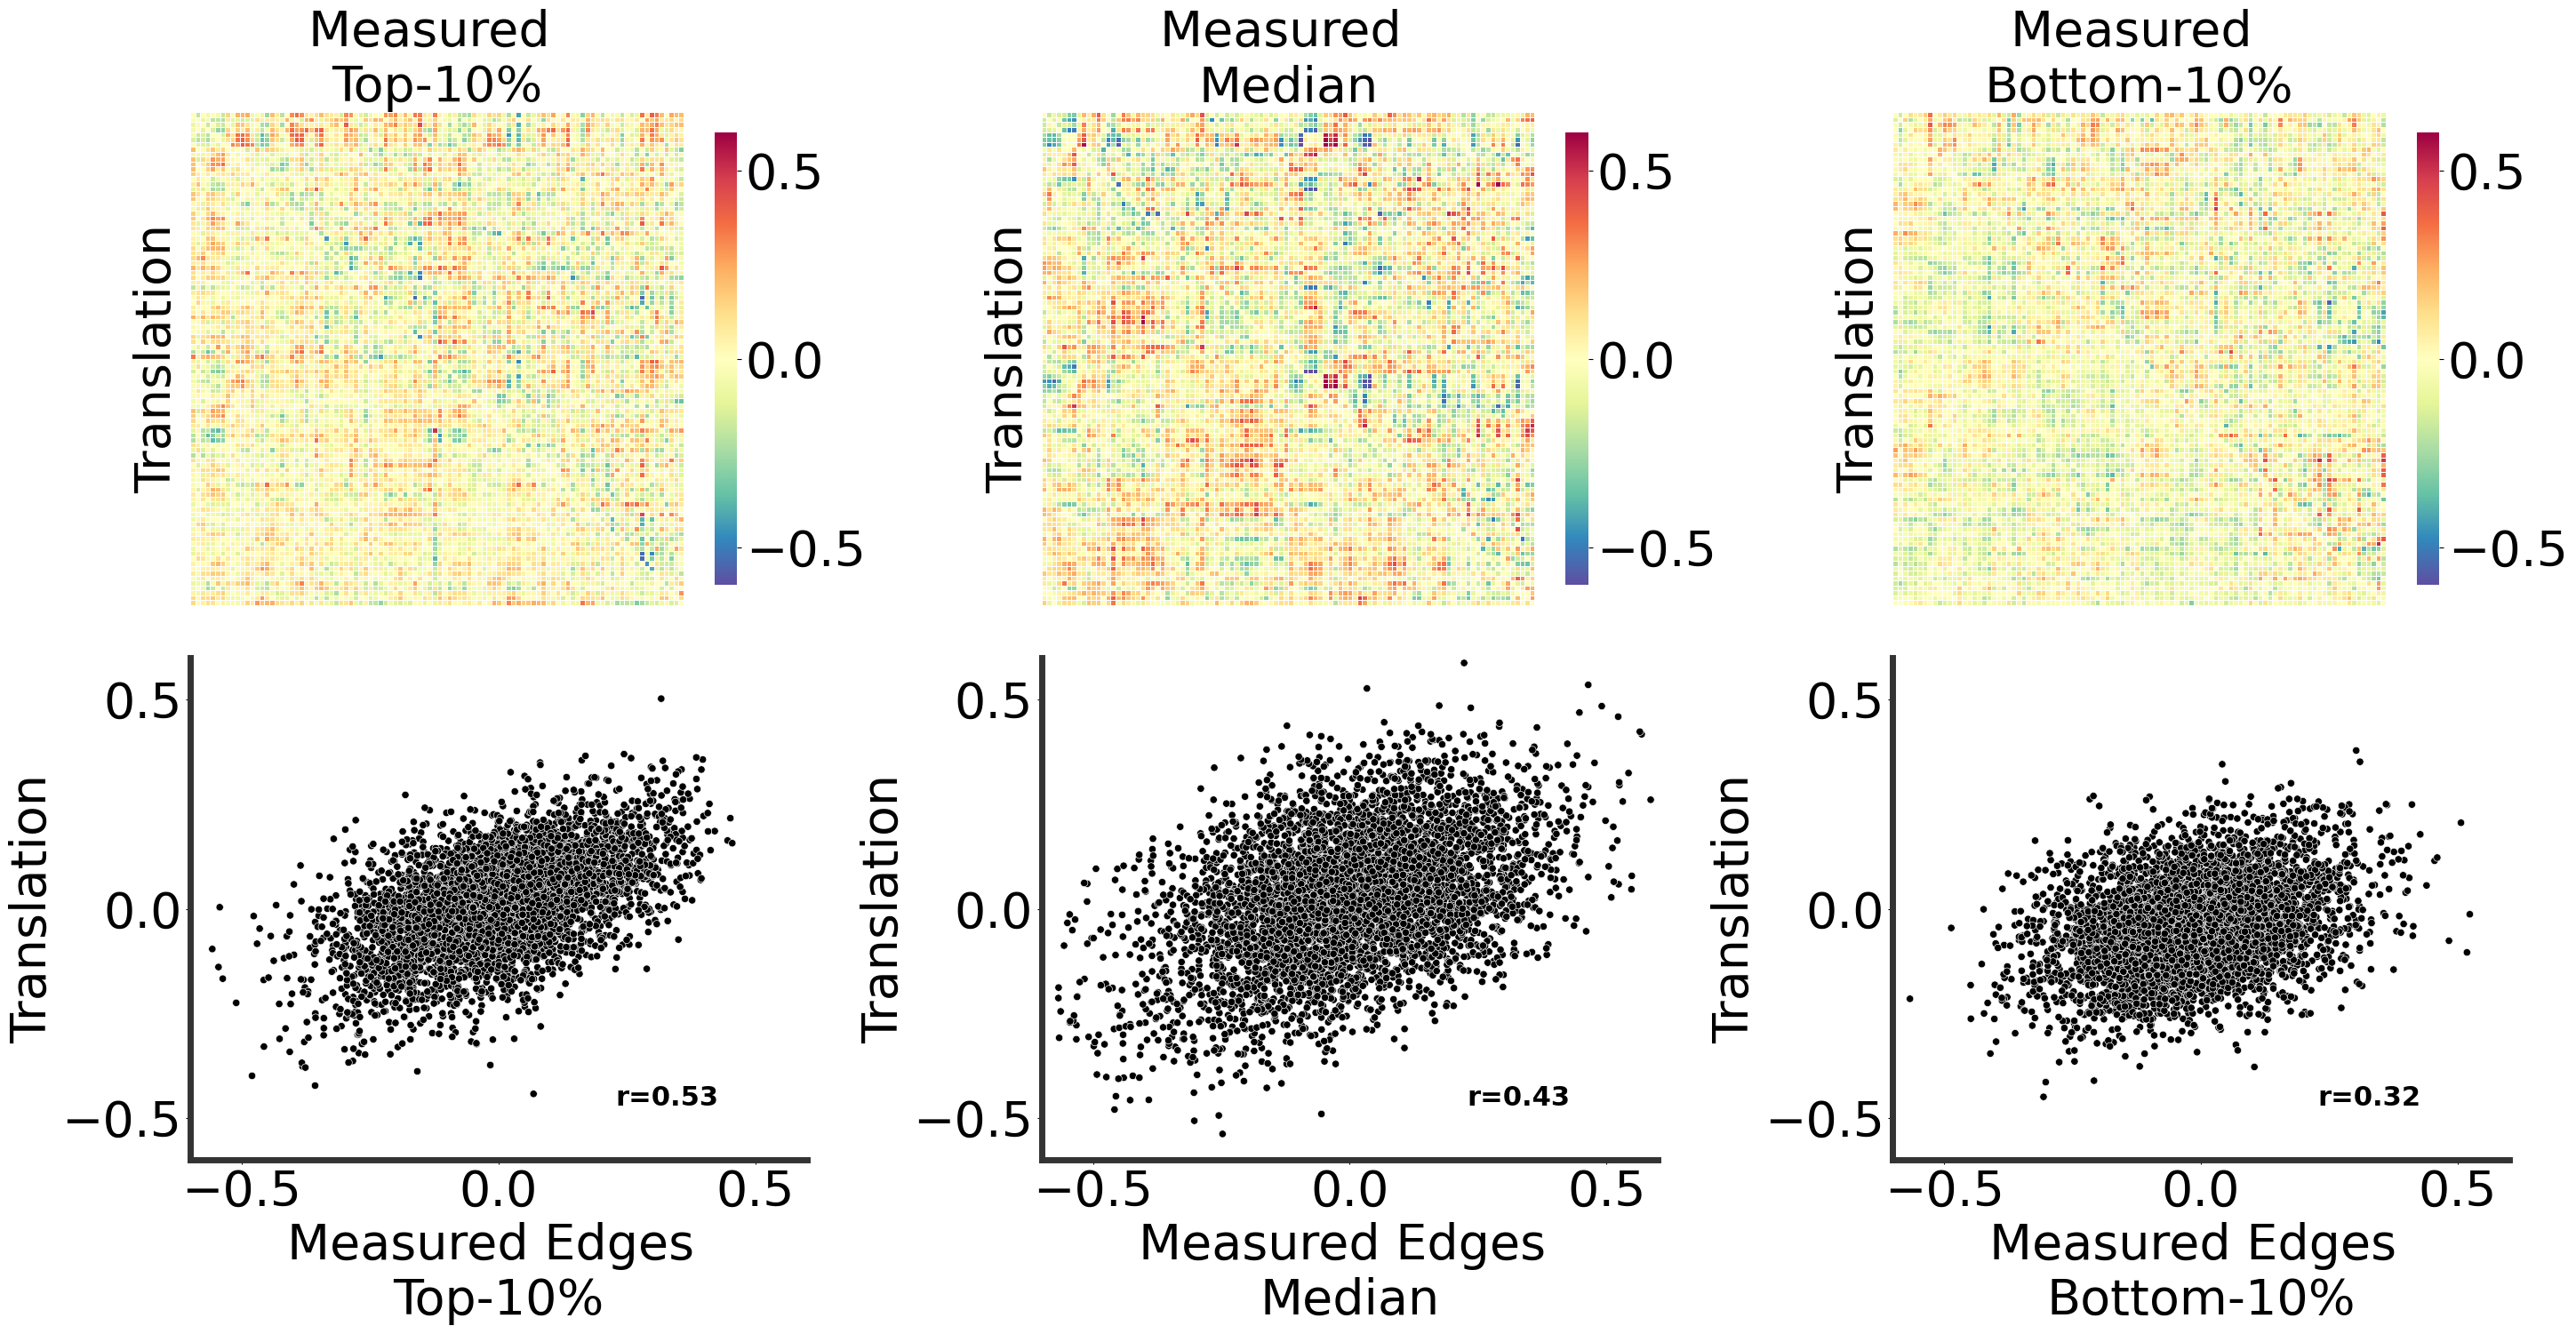

In [33]:
ica_reconstuction=0
iidx_model=cc
if not ica_reconstuction:

    train_true_netmats = train_truth_holder #+ train_mean_flatten_pred
    train_pred_netmats = train_pred_holder #+ train_mean_flatten_true
    test_true_netmats = test_truth_holder #+ test_mean_flatten_pred
    test_pred_netmats = test_pred_holder #+ test_mean_flatten_true

    train_true = make_nemat_allsubj_triangle_only(train_true_netmats,from_parcellation_list[iidx_model], True)
    train_pred = make_nemat_allsubj_triangle_only(train_pred_netmats,from_parcellation_list[iidx_model], False)
    test_true = make_nemat_allsubj_triangle_only(test_true_netmats,from_parcellation_list[iidx_model], True)
    test_pred = make_nemat_allsubj_triangle_only(test_pred_netmats,from_parcellation_list[iidx_model], False)

    '''
    Going to view random subjects, but for this plot, we want random in top 10 percent of performance. Above, we find those.
    So here, we get 2 random numbers and use that as indeces of the top_10_percent s.t. we pick any two random people and thier true/pred
    matrices to visualize below.
    '''
    # for kk in range(2):
    #     x = np.random.randint(0,len(top_10_percent_indeces)) #random but for index so we get actual subject idx for viewing
    #     subs2view.append(top_10_percent_indeces[x])
    '''
    Going to view random subjects, but for this plot, we want random in top 10 percent of performance. Above, we find those.
    So here, we get 2 random numbers and use that as indeces of the top_10_percent s.t. we pick any two random people and thier true/pred
    matrices to visualize below.
    '''
    subs2view=[]
    for kk in range(1):
        # x = np.random.randint(0,len(top_10_percent_indeces)) #random but for index so we get actual subject idx for viewing
        # subs2view.append(top_10_percent_indeces[x])
        # subs2view.append(get_median_idx[0]) #only one median
        # x2 = np.random.randint(0,len(bottom_10_percent_indeces))
        # subs2view.append(bottom_10_percent_indeces[x2])

        # choose them manually
        subs2view.append(372)
        subs2view.append(498) #only one median
        subs2view.append(299)


    # subs2view = [0, 100, 200, 300, 500, 700]
    fig, axes = plt.subplots(2,3, figsize=(30, 16))
    axes = axes.flatten()
    # mask = np.tril(np.ones_like(test_true[0], dtype=bool))
    # mask_only_show_lower=np.triu(np.ones_like(test_true[0], dtype=bool))
    # for i in range(len(subs2view)):
    shrink_val=0.9
    sns.heatmap(test_true[subs2view[0]]+test_pred[subs2view[0]],cmap='Spectral_r', vmin=-0.6, vmax=0.6, cbar_kws={"shrink": shrink_val}, center=0,
        square=True, linewidths=.5, xticklabels=False, yticklabels=False, ax=axes[0])
    axes[0].set_title("Measured \nTop-10%", fontsize=40)
    axes[0].set_ylabel("Translation")

    sns.heatmap(test_true[subs2view[1]]+test_pred[subs2view[1]], cmap='Spectral_r', vmin=-0.6, vmax=0.6, cbar_kws={"shrink": shrink_val}, center=0,
        square=True, linewidths=.5, xticklabels=False, yticklabels=False, ax=axes[1])
    axes[1].set_title("Measured \nMedian", fontsize=40)
    axes[1].set_ylabel("Translation")

    sns.heatmap(test_true[subs2view[2]]+test_pred[subs2view[2]], cmap='Spectral_r', vmin=-0.6, vmax=0.6, cbar_kws={"shrink": shrink_val}, center=0,
        square=True, linewidths=.5, xticklabels=False, yticklabels=False, ax=axes[2])
    axes[2].set_title("Measured \nBottom-10%", fontsize=40)
    axes[2].set_ylabel("Translation")
    # axes[2].set_ylabel(f"Bottom 10%", fontsize=28)

    print(f"XXX: {len(test_pred_netmats[subs2view[0]])}")
    print(f"XXX: {len(test_true_netmats[subs2view[0]])}")
    names_list_for_all = ["Measured Edges \nTop-10%","Translation \nTop-10%","Measured Edges \nMedian","Translation \nMedian","Measured Edges \nBottom-10%","Translation \nBottom-10%"]
    df_scatter_mats = pd.DataFrame({
    "Measured Edges \nTop-10%": test_true_netmats[subs2view[0]],
    "Translation \nTop-10%": test_pred_netmats[subs2view[0]],
    "Measured Edges \nMedian": test_true_netmats[subs2view[1]],
    "Translation \nMedian": test_pred_netmats[subs2view[1]],
    "Measured Edges \nBottom-10%": test_true_netmats[subs2view[2]],
    "Translation \nBottom-10%": test_pred_netmats[subs2view[2]],
})

    # xii=0
    img_count=0
    for xii in range(3,6):
        scatter_fig = sns.scatterplot(df_scatter_mats, x=names_list_for_all[img_count],y=names_list_for_all[img_count+1], hue=names_list_for_all[img_count+1], ax=axes[xii],legend=False, palette=["black"])
        for ax in ['bottom', 'left']:
            axes[xii].spines[ax].set_linewidth(5)
            axes[xii].spines[ax].set_color('0.2')
        axes[xii].spines['top'].set_visible(False)
        axes[xii].spines['right'].set_visible(False)
        axes[xii].set_xticks([-0.5, 0, 0.5])
        axes[xii].set_yticks([-0.5, 0, 0.5])
        axes[xii].set_xlabel(f"{names_list_for_all[img_count]}",fontsize=40)
        # axes[xii].set_ylabel(f"{names_list_for_all[img_count+1]}")
        axes[xii].set_ylabel(f"Translation")
        axes[xii].set_xlim([-0.6,0.6])
        axes[xii].set_ylim([-0.6,0.6])
        # scatter_fig.limit(x=(-0.8,0.8), y=(-0.8,0.8))
        
        img_count+=2
        metric_accuracy_sub = test_rho_chnl[subs2view[xii-3]]
        print(metric_accuracy_sub)
        corr_text="r={:.2f}".format(float(metric_accuracy_sub))
        axes[xii].text(0.69, 0.15, corr_text, transform=axes[xii].transAxes, fontsize=22, verticalalignment='top',weight="bold")
        # axes[xii].plot(np.unique(truebb_fluid), np.poly1d(np.polyfit(truebb_fluid, predbb_fluid, 1))(np.unique(truebb_fluid)), 'r--')

    plt.tight_layout()
    filename = f"/examples_netmats_test_{from_parcellation_list[iidx_model]}.{img_extension}"
    print(f"Saving to path:{directory}")
    # Save the figure
    if not local_flag:
        plt.savefig(directory + filename, format=img_extension)
    plt.show()
    plt.close()

In [36]:
# local_flag=False
## combine across models
#reconstruction, needs to be averaged across 15 TRUE and PRED then use that as swarmplots
# ICA reconstruction
# translation_ica="ICAd15_ICAd15" #f"ICAd15_{from_atlas}d{from_parcellation}" # needs to be "" type of string
version_ica = "normICAnormICA" #over ride what it was prior
chnl_list = np.arange(0,15).tolist()
combined_ica_maps_list = []
mean_list_icaica=[]
sd_list_icaica=[]
for cci in range(len(chnl_list)):

    chnl_icarecon = chnl_list[cci] #0-14
    model_details=f"120425_d6h3_tiny_adamW_cosinedecay_reconICA_MSEtrain_expICARECON_chnl{chnl_icarecon}"

    directory_icarecon = root + '/images/ABCD/ICAd15_ICAd15/' + model_type +'/' + version_ica + '/' + model_details + '/' + model_test_type 
    translation_ica_ica = pd.read_csv(directory_icarecon+'/allsubjects_individual_true_pred_testavg.csv')
    translation_ica_ica_curr_chnl = translation_ica_ica[translation_ica_ica['group'] == 'TEST_dmn'] #filter to get test_demean only
    translation_ica_ica_curr_chnl_np = np.asarray(translation_ica_ica_curr_chnl["value"])
    mean_list_icaica.append(np.mean(translation_ica_ica_curr_chnl_np)) #mean for that channel
    sd_list_icaica.append(np.std(translation_ica_ica_curr_chnl_np)) #standard deviation for that channel
    print(f"Chnl mean:{mean_list_icaica[cci]:.2f} sd:{sd_list_icaica[cci]:.2f}")
    combined_ica_maps_list.append(translation_ica_ica_curr_chnl_np) #15,624
# print(np.asarray(combined_ica_maps_list).shape)
combined_ica_maps = np.asarray(combined_ica_maps_list) #array of 15,624
mean_flat_icas = np.mean(combined_ica_maps.flatten())
sd_flat_icas = np.std(combined_ica_maps.flatten())
print(f"ICA recon average:{mean_flat_icas:.2f} & SD:{sd_flat_icas:.2f}")

# find top,bottom,med for ICAs
# ## linear 
# combined_ica_maps_linear_list = []
# mean_list_icaica=[]
# sd_list_icaica=[]
# for cci in range(len(chnl_list)):
#     chnl_icarecon = chnl_list[cci] #0-14
#     model_details=f"122925_d6h3_tiny_adamW_cosinedecay_reconICA_MSEtrain_expICARECON_linear_chnl{chnl_icarecon}"

#     directory_icarecon = root + '/images/ABCD/ICAd15_ICAd15/' + model_type +'/' + version_ica + '/' + model_details + '/' + model_test_type 
#     try:
#         translation_ica_ica = pd.read_csv(directory_icarecon+'/allsubjects_individual_true_pred_testavg.csv')
#         translation_ica_ica_curr_chnl = translation_ica_ica[translation_ica_ica['group'] == 'TEST_dmn'] #filter to get test_demean only
#         translation_ica_ica_curr_chnl_np = np.asarray(translation_ica_ica_curr_chnl["value"])
#         mean_list_icaica.append(np.mean(translation_ica_ica_curr_chnl_np)) #mean for that channel
#         sd_list_icaica.append(np.std(translation_ica_ica_curr_chnl_np)) #standard deviation for that channel
#         print(f"Chnl mean:{mean_list_icaica[cci]:.2f} sd:{sd_list_icaica[cci]:.2f}")
#     except:
#         print(f"Channel--{cci} does not have data so making zero for now.")
#         translation_ica_ica_curr_chnl_np = np.zeros((624,))
#         mean_list_icaica.append(np.mean(translation_ica_ica_curr_chnl_np)) #mean for that channel
#         sd_list_icaica.append(np.std(translation_ica_ica_curr_chnl_np)) #standard deviation for that channel
#         print(f"Chnl mean:{mean_list_icaica[cci]:.2f} sd:{sd_list_icaica[cci]:.2f}")
        
#     # print(f"What goes into the list: {translation_ica_ica_curr_chnl_np.shape}")
#     combined_ica_maps_linear_list.append(translation_ica_ica_curr_chnl_np)
# combined_ica_maps_linear = np.asarray(combined_ica_maps_linear_list) #array of 15,624
# # print(combined_ica_maps_linear.shape)
# mean_flat_icas_linear = np.mean(combined_ica_maps_linear.flatten())
# sd_flat_icas_linear = np.std(combined_ica_maps_linear.flatten())
# print(f"ICA recon LINEAR average:{mean_flat_icas_linear:.2f} & SD:{sd_flat_icas_linear:.2f}")


#schf100
model_details="120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp100_wGelu"
# model_details=f"011426_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp{from_parcellation}_wGelu_ico0{icores}"
directory100 = root + '/images/ABCD/ICAd15_schfd100/' + model_type +'/' + version + '/' + model_details + '/' +model_test_type 
# print(directory100+'/allsubjects_individual_true_pred_testavg.csv')
translation_ica_schf100 = pd.read_csv(directory100+'/allsubjects_individual_true_pred_testavg.csv')
# print(translation_ica_schf100)
translation_ica_schf100 = translation_ica_schf100[translation_ica_schf100['group'] == 'TEST_dmn'] #filter to get test_demean only
# print(translation_ica_schf100)
print(f"schf100 average:{np.mean(translation_ica_schf100)} SD:{np.std(translation_ica_schf100)}")

#schf100_partial
model_details="120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_Partial_demean_exp100_wGelu"
directory100_partial = root + '/images/ABCD/ICAd15_schfd100/' + model_type +'/' + version + '/' + model_details + '/' +model_test_type 
# print(directory100+'/allsubjects_individual_true_pred_testavg.csv')
translation_ica_schf100_partial = pd.read_csv(directory100_partial+'/allsubjects_individual_true_pred_testavg.csv')
# print(translation_ica_schf100_partial)
translation_ica_schf100_partial = translation_ica_schf100_partial[translation_ica_schf100_partial['group'] == 'TEST_dmn'] #filter to get test_demean only
# print(translation_ica_schf100_partial)
print(f"schf100 partial average:{np.mean(translation_ica_schf100_partial)} SD:{np.std(translation_ica_schf100_partial)}")

# #schf100_HCP
# model_details="120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp100_wGelu"
# directory100_hcp = root + '/images/HCPYA_ABCDdr/ICAd15_schfd100/' + model_type +'/' + version + '/' + model_details + '/' + model_test_type 
# translation_ica_schf100_hcp = pd.read_csv(directory100_hcp+'/allsubjects_individual_true_pred_testavg.csv')
# translation_ica_schf100_hcp = translation_ica_schf100_hcp[translation_ica_schf100_hcp['group'] == '$TEST_{dmn}$'] #filter to get test_demean only
# print(f"schf100 HCP average:{np.mean(translation_ica_schf100_hcp)} SD:{np.std(translation_ica_schf100_hcp)}")

#schf300
model_details="120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp300_wGelu"
directory300 = root + '/images/ABCD/ICAd15_schfd300/' + model_type +'/' + version + '/' + model_details + '/' +model_test_type 
translation_ica_schf300 = pd.read_csv(directory300+'/allsubjects_individual_true_pred_testavg.csv')
translation_ica_schf300 = translation_ica_schf300[translation_ica_schf300['group'] == 'TEST_dmn'] #filter to get test_demean only
# print(translation_ica_schf300)
print(f"schf300 average:{np.mean(translation_ica_schf300)} SD:{np.std(translation_ica_schf300)}")

#glasser360
model_details="120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp360_wGelu"
directory360 = root + '/images/ABCD/ICAd15_glasserd360/' + model_type +'/' + version + '/' + model_details + '/' +model_test_type 
translation_ica_glass360 = pd.read_csv(directory360+'/allsubjects_individual_true_pred_testavg.csv')
translation_ica_glass360 = translation_ica_glass360[translation_ica_glass360['group'] == 'TEST_dmn'] #filter to get test_demean only
# print(translation_ica_glass360)
print(f"glass360 average:{np.mean(translation_ica_glass360)} SD:{np.std(translation_ica_glass360)}")

df_list = []
df_all = pd.DataFrame({
    "Values": np.concatenate([translation_ica_schf100["value"], translation_ica_schf100_partial["value"], translation_ica_schf300["value"], translation_ica_glass360["value"]]),
    "Groups": ["Schaefer\n100"] * len(translation_ica_schf100)
    + ["Schaefer\n100 PC"] * len(translation_ica_schf100_partial)
    + ["Schaefer\n300"] * len(translation_ica_schf300) 
    + ["Glasser\n360"] * len(translation_ica_glass360)
    # + ["Schaefer 100 HCP"] * len(translation_ica_schf100_hcp)
    # "Comparison": ["Full-Partial"] + ["Dimensionality"] + ["Type"]
})
df_list.append(df_all)


# df_all1 = pd.DataFrame({
#     "Values": np.concatenate([translation_ica_schf100["value"], translation_ica_schf100_partial["value"]]),
#     "Groups": ["Schaefer 100"] * len(translation_ica_schf100) + ["Schaefer 100 Partial"] * len(translation_ica_schf100_partial)})
# df_list.append(df_all1)
# df_list_palette.append(['r','lightsalmon'])
# df_all2 = pd.DataFrame({
#     "Values": np.concatenate([translation_ica_schf100["value"], translation_ica_schf300["value"]]),
#     "Groups": ["Schaefer 100"] * len(translation_ica_schf100) + ["Schaefer 300"] * len(translation_ica_schf300)})
# df_list.append(df_all2)
# df_list_palette.append(['r','darkred'])
# df_all3 = pd.DataFrame({
#     "Values": np.concatenate([translation_ica_schf100["value"], translation_ica_glass360["value"]]),
#     "Groups": ["Schaefer 100"] * len(translation_ica_schf100) + ["Glasser 360"] * len(translation_ica_glass360)})
# df_list.append(df_all3)
# df_list_palette.append(['r','darkcyan'])

# other figrue showing each ICA map reconstruction accuracy
individual_ica_maps = combined_ica_maps_list #np.asarray(combined_ica_maps_list)
# individual_ica_maps_list = combined_ica_maps_linear_list
print(len(individual_ica_maps))
test_subject_length = int(individual_ica_maps[0].shape[0]) #same across all channels so its fine to pick first one==0
# print(len(individual_ica_maps),test_subject_length,individual_ica_maps[0].shape)
df_ica_individual = pd.DataFrame({
    "Values":  np.concatenate([individual_ica_maps[0], individual_ica_maps[1], individual_ica_maps[2], individual_ica_maps[3],
               individual_ica_maps[4], individual_ica_maps[5], individual_ica_maps[6], individual_ica_maps[7],
               individual_ica_maps[8], individual_ica_maps[9], individual_ica_maps[10], individual_ica_maps[11],
               individual_ica_maps[12], individual_ica_maps[13], individual_ica_maps[14]]),
            #    individual_ica_maps_list[0], individual_ica_maps_list[1], individual_ica_maps_list[2], individual_ica_maps_list[3],
            #    individual_ica_maps_list[4], individual_ica_maps_list[5], individual_ica_maps_list[6], individual_ica_maps_list[7],
            #    individual_ica_maps_list[8], individual_ica_maps_list[9], individual_ica_maps_list[10], individual_ica_maps_list[11], 
            #    individual_ica_maps_list[12], individual_ica_maps_list[13], individual_ica_maps_list[14]]),
    "Groups": ["Brain Map 1"] * test_subject_length
    + ["Brain Map 2"] * test_subject_length + ["Brain Map 3"] * test_subject_length
    + ["Brain Map 4"] * test_subject_length + ["Brain Map 5"] * test_subject_length
    + ["Brain Map 6"] * test_subject_length + ["Brain Map 7"] * test_subject_length
    + ["Brain Map 8"] * test_subject_length + ["Brain Map 9"] * test_subject_length
    + ["Brain Map 10"] * test_subject_length + ["Brain Map 11"] * test_subject_length
    + ["Brain Map 12"] * test_subject_length + ["Brain Map 13"] * test_subject_length
    + ["Brain Map 14"] * test_subject_length + ["Brain Map 15"] * test_subject_length})
    # + ["Brain Map 1"] * test_subject_length
    # + ["Brain Map 2"] * test_subject_length + ["Brain Map 3"] * test_subject_length
    # + ["Brain Map 4"] * test_subject_length + ["Brain Map 5"] * test_subject_length
    # + ["Brain Map 6"] * test_subject_length + ["Brain Map 7"] * test_subject_length
    # + ["Brain Map 8"] * test_subject_length + ["Brain Map 9"] * test_subject_length
    # + ["Brain Map 10"] * test_subject_length + ["Brain Map 11"] * test_subject_length
    # + ["Brain Map 12"] * test_subject_length + ["Brain Map 13"] * test_subject_length
    # + ["Brain Map 14"] * test_subject_length + ["Brain Map 15"] * test_subject_length,
    # "Types": ["SiT"]*test_subject_length*(15) + ["Linear"]*test_subject_length*(15)})


Chnl mean:0.88 sd:0.01
Chnl mean:0.82 sd:0.02
Chnl mean:0.73 sd:0.03
Chnl mean:0.76 sd:0.02
Chnl mean:0.75 sd:0.03
Chnl mean:0.62 sd:0.04
Chnl mean:0.67 sd:0.04
Chnl mean:0.74 sd:0.03
Chnl mean:0.71 sd:0.03
Chnl mean:0.79 sd:0.02
Chnl mean:0.65 sd:0.03
Chnl mean:0.58 sd:0.04
Chnl mean:0.84 sd:0.02
Chnl mean:0.75 sd:0.03
Chnl mean:0.65 sd:0.03
ICA recon average:0.73 & SD:0.09


/Users/snaranjo/miniconda3/envs/dahan_optimus/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/snaranjo/miniconda3/envs/dahan_optimus/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3579: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


schf100 average:Unnamed: 0    14519.500000
value             0.427666
dtype: float64 SD:Unnamed: 0    180.133053
value           0.076792
dtype: float64
schf100 partial average:Unnamed: 0    14519.500000
value             0.151857
dtype: float64 SD:Unnamed: 0    180.133053
value           0.037493
dtype: float64
schf300 average:Unnamed: 0    14519.500000
value             0.320619
dtype: float64 SD:Unnamed: 0    180.133053
value           0.062278
dtype: float64
glass360 average:Unnamed: 0    14519.500000
value             0.319963
dtype: float64 SD:Unnamed: 0    180.133053
value           0.056143
dtype: float64
15


Saving to path:/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/scienceadv_image


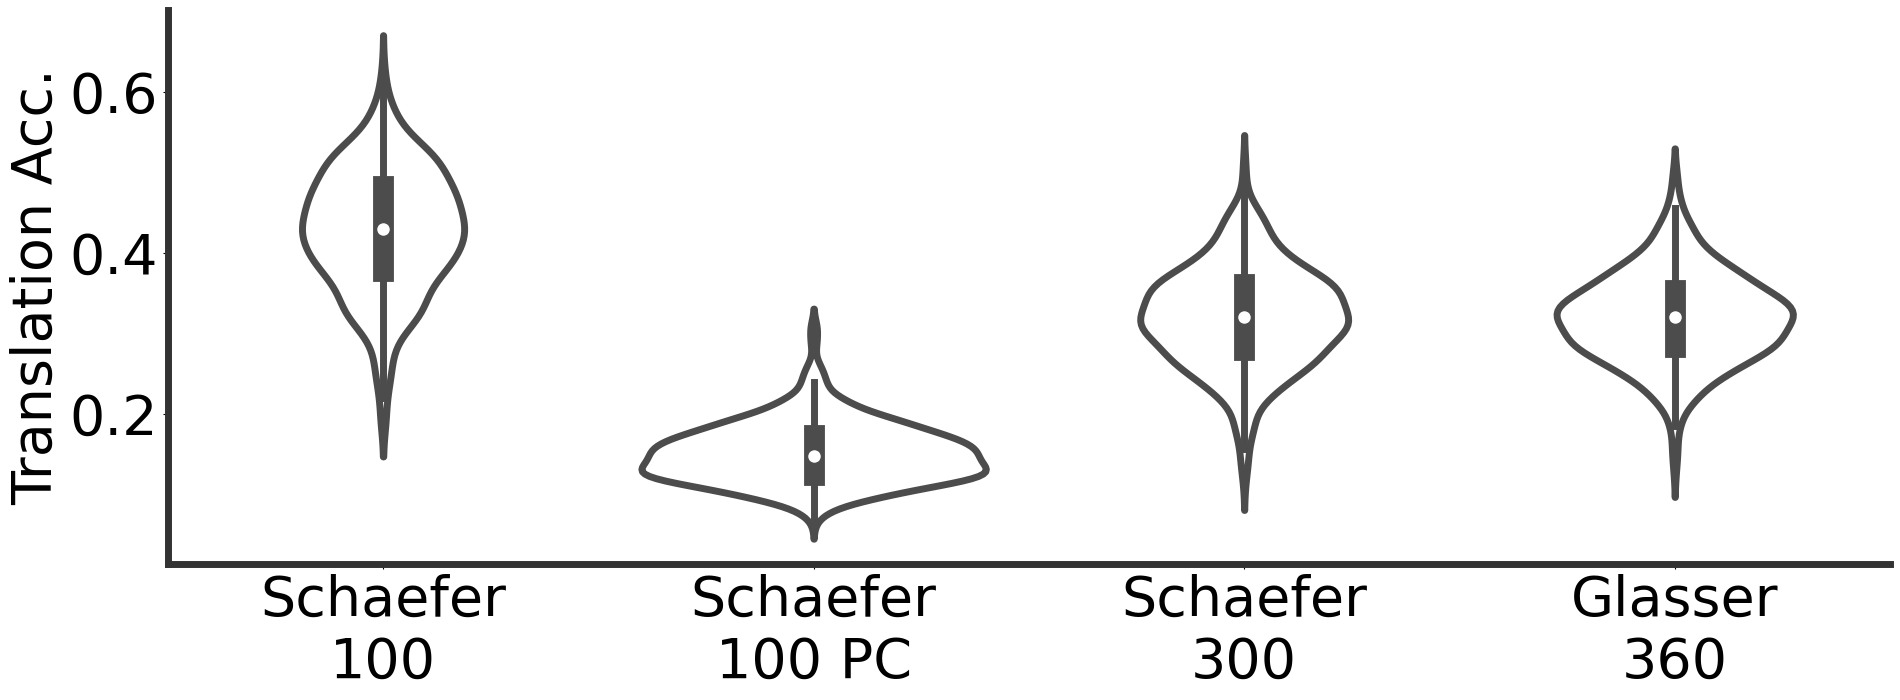

Saving to path:/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/scienceadv_image


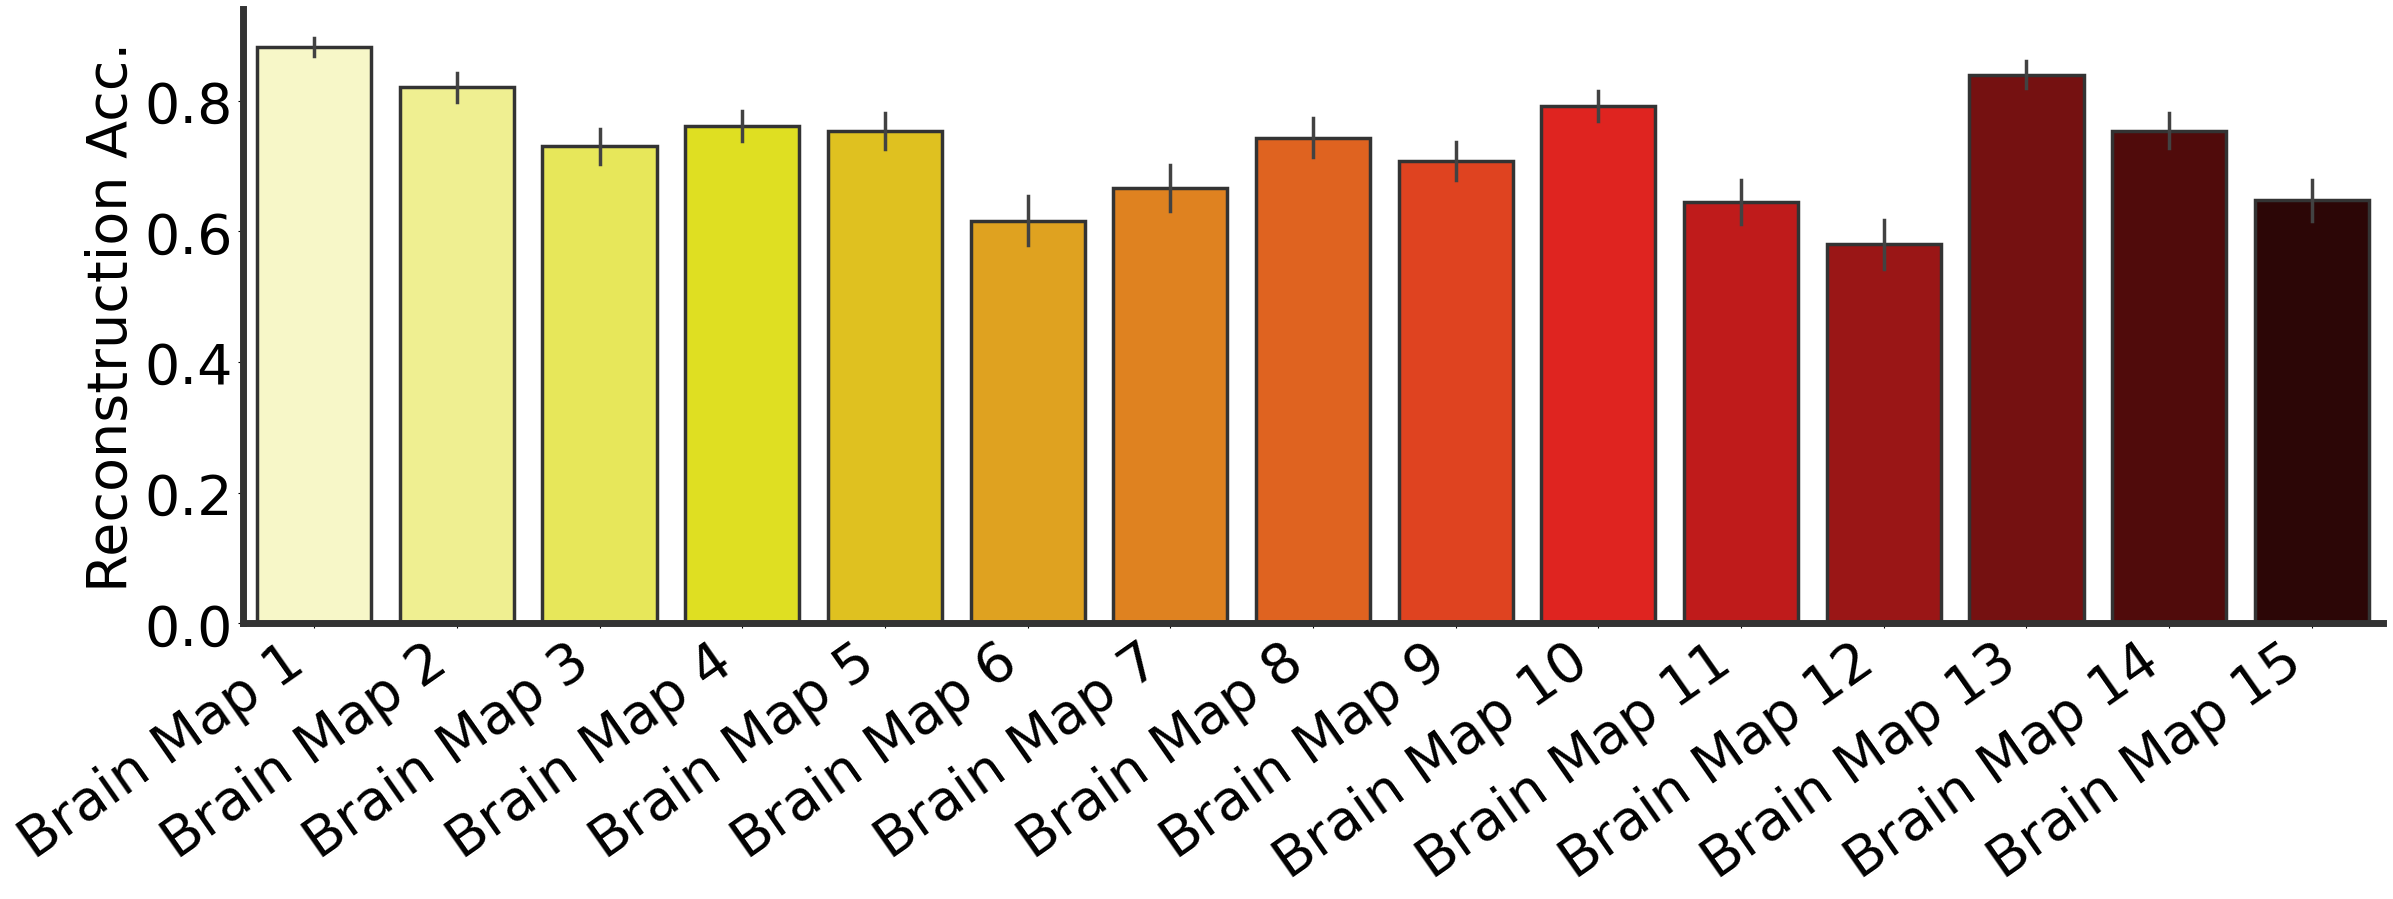

In [37]:
from matplotlib.colors import to_rgba
df_list_palette=[]
df_list_palette.append(['gray','lightsalmon','red','cyan'])
if len(df_list)==1:
    fig = plt.figure(figsize=(20, 8))
    for iii in range(len(df_list)):
        # axxx=sns.barplot(df_list[iii], x="Groups", y="Values", hue="Groups", orient="v", estimator='mean', errorbar="sd",
        #     edgecolor='0.2',lw=2.5,errwidth=2.5, dodge=False, palette=df_list_palette[iii],)
        
        # axxx=sns.violinplot(df_list[iii], x="Groups", y="Values", palette=df_list_palette[iii],linewidth=5.0,legend=False)

        axxx=sns.violinplot(df_list[iii], x="Groups", y="Values", palette=df_list_palette[iii], linewidth=5)
        for violin, alpha in zip(axxx.collections[::2], [0, 0, 0, 0]):
            violin.set_facecolor(to_rgba(violin.get_facecolor(), alpha=alpha))

else:
    fig, axes = plt.subplots(1,len(df_list), figsize=(18, 10))
    axes=axes.flatten()
    for iii in range(len(df_list)):
        axxx=sns.barplot(df_list[iii], x="Groups", y="Values", hue="Groups", orient="v", estimator='mean', errorbar="sd",
            edgecolor='0.2',lw=2.5,errwidth=2.5, dodge=False, palette=df_list_palette[iii], ax=axes[iii])
    axxx.get_legend().remove()
for ax in ['bottom','left']:
    axxx.spines[ax].set_linewidth(5)
    axxx.spines[ax].set_color('0.2')
axxx.spines['top'].set_visible(False)
axxx.spines['right'].set_visible(False)
# axxx.set_xticklabels(axxx.get_xticklabels(), rotation=35, ha='right')
axxx.set_ylabel("Translation Acc.")
axxx.set_xlabel("")

filename = f"/violinplot_plot_avgRecon_translations_100_300_360.{img_extension}"
print(f"Saving to path:{directory}")
plt.tight_layout()
# Save the figure
if not local_flag:
    plt.savefig(directory + filename, format=img_extension)
plt.show()


fig = plt.figure(figsize=(25, 10))
# ax=sns.swarmplot(df_ica_individual, x="Groups", y="Values", hue="Groups", legend=False, size=4)
ax=sns.barplot(df_ica_individual, x="Groups", y="Values", orient="v", estimator='mean', errorbar="sd",
                 edgecolor='0.2',lw=2.5,errwidth=2.5, dodge=False, palette="hot_r") #palette=['black','gray'], palette="hot_r", palette=['brown','lightsalmon','mistyrose']
# ax.get_legend().remove() #if using bar plot
for axii in ['bottom','left']:
       ax.spines[axii].set_linewidth(5)
       ax.spines[axii].set_color('0.2')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.set_ylabel("Reconstruction Acc.")
ax.set_xlabel("")
filename = f"/bar_plot_ica_reconstruction.{img_extension}"
print(f"Saving to path:{directory}")
plt.tight_layout()
# Save the figure
if not local_flag:
    plt.savefig(directory + filename, format=img_extension)
plt.show()

In [38]:
#10% number calc
ten_perc_calc = int(0.1*combined_ica_maps.shape[1])
print(f"Ten percent of Test is: {ten_perc_calc}")
viz_channel = combined_ica_maps[0] #(624,)
dmn_channel = combined_ica_maps[3]
#sorted lowest to highest
viz_sort=np.sort(viz_channel)
dmn_sort=np.sort(dmn_channel)

#top 10
viz_top10_val = viz_sort[-ten_perc_calc:]
dmn_top10_val = dmn_sort[-ten_perc_calc:]
print(viz_top10_val[:2])
viz_top_idx=[]
dmn_top_idx=[]
for idx in range(len(viz_top10_val)):
    find_idx = np.argwhere(viz_channel==viz_top10_val[idx])
    viz_top_idx.append(find_idx)
    find_idx = np.argwhere(dmn_channel==dmn_top10_val[idx])
    dmn_top_idx.append(find_idx)

viz_top_idx_np = np.array(viz_top_idx).squeeze().squeeze()
dmn_top_idx_np = np.array(dmn_top_idx).squeeze().squeeze()
print("Top")
print("viz")
print(np.sort(viz_top_idx_np))
print("dmn")
print(np.sort(dmn_top_idx_np))

#bottom 10
viz_bottom10_val = viz_sort[:ten_perc_calc]
dmn_bottom10_val = dmn_sort[:ten_perc_calc]
print(viz_bottom10_val[:2])
viz_bottom_idx=[]
dmn_bottom_idx=[]
for idx in range(len(viz_bottom10_val)):
    find_idx = np.argwhere(viz_channel==viz_bottom10_val[idx])
    viz_bottom_idx.append(find_idx)
    find_idx = np.argwhere(dmn_channel==dmn_bottom10_val[idx])
    dmn_bottom_idx.append(find_idx)

viz_bottom_idx_np = np.array(viz_bottom_idx).squeeze().squeeze()
dmn_bottom_idx_np = np.array(dmn_bottom_idx).squeeze().squeeze()
print()
print("Bottom")
print("viz")
print(np.sort(viz_bottom_idx_np))
print("dmn")
print(np.sort(dmn_bottom_idx_np))

#median
viz_med_val = [viz_sort[len(viz_channel)//2]]
dmn_med_val = [dmn_sort[len(dmn_channel)//2]]
print(viz_med_val)
# viz_med_idx=[]
# dmn_med_idx=[]
find_idx = np.argwhere(viz_channel==viz_med_val[0]).squeeze()
viz_med_idx_np = [find_idx]
find_idx = np.argwhere(dmn_channel==dmn_med_val[0]).squeeze()
dmn_med_idx_np = [find_idx]

print((viz_med_idx_np), dmn_med_idx_np)

Ten percent of Test is: 62
[0.8995291  0.89959579]
Top
viz
[  8  11  13  14  28  42  46  52  54  62  69  70  92  96  98 126 127 155
 190 191 201 205 206 207 215 233 256 262 272 287 288 298 319 327 331 335
 347 367 369 381 393 400 402 421 428 430 431 450 474 501 510 514 525 540
 549 551 567 578 605 607 609 623]
dmn
[  1  20  24  39  50  65  67  70  77  85  86  88 106 124 125 141 161 163
 168 176 177 181 203 206 208 214 230 235 236 238 241 243 254 256 262 266
 271 307 320 368 374 383 384 419 431 439 456 470 479 482 515 516 539 543
 565 589 593 595 598 599 619 621]
[0.84528987 0.84576116]

Bottom
viz
[  3  12  18  49  53  59  74  77  82  87  88 103 117 146 147 170 172 173
 174 181 199 216 217 227 253 258 267 268 273 275 294 302 314 320 332 337
 338 373 374 403 424 435 437 443 444 458 468 470 471 495 496 508 509 516
 534 547 581 588 600 611 613 621]
dmn
[  9  15  16  36  43  48  71  73  78  82  91  97 103 104 114 119 128 129
 131 159 167 174 175 178 190 192 215 248 250 269 273 291 295 315 

In [39]:
'''
Looking to see if ICA brain maps have a lot of variabiltiy in their initial composition.
Purpose is to see if translation accuracy has anything to do with that, i.e., do subjects with outlier like ICA maps produce worse parcellations?
We investigated this for true connectomes and found no such relationship.
'''

# cci = 0
for cci in range(len(chnl_list)):
    chnl_icarecon = chnl_list[cci] #0-14
    model_details=f"120425_d6h3_tiny_adamW_cosinedecay_reconICA_MSEtrain_expICARECON_chnl{chnl_icarecon}"
    get_chanel_sd = np.load(f"{root}/images/ABCD/ICAd15_ICAd15/{model_type}/{version_ica}/{model_details}/{model_test_type}/std_channel_{chnl_icarecon}.npy")
    print(f"Channel Loaded: {chnl_icarecon}\n Mean:{np.mean(get_chanel_sd,axis=0)} --- SD: {np.std(get_chanel_sd,axis=0)}")
    # channel_
    
# df_ica_individual = pd.DataFrame({
#     "Values":  np.concatenate([individual_ica_maps[0], individual_ica_maps[1], individual_ica_maps[2], individual_ica_maps[3],
#                individual_ica_maps[4], individual_ica_maps[5], individual_ica_maps[6], individual_ica_maps[7],
#                individual_ica_maps[8], individual_ica_maps[9], individual_ica_maps[10], individual_ica_maps[11],
#                individual_ica_maps[12], individual_ica_maps[13], individual_ica_maps[14]]),#
#             #    individual_ica_maps_list[0], individual_ica_maps_list[1], individual_ica_maps_list[2], individual_ica_maps_list[3],
#             #    individual_ica_maps_list[4], individual_ica_maps_list[5], individual_ica_maps_list[6], individual_ica_maps_list[7],
#             #    individual_ica_maps_list[8], individual_ica_maps_list[9], individual_ica_maps_list[10], individual_ica_maps_list[11], 
#             #    individual_ica_maps_list[12], individual_ica_maps_list[13], individual_ica_maps_list[14]]),
#     "Groups": ["Brain Map 1"] * test_subject_length
#     + ["Brain Map 2"] * test_subject_length + ["Brain Map 3"] * test_subject_length
#     + ["Brain Map 4"] * test_subject_length + ["Brain Map 5"] * test_subject_length
#     + ["Brain Map 6"] * test_subject_length + ["Brain Map 7"] * test_subject_length
#     + ["Brain Map 8"] * test_subject_length + ["Brain Map 9"] * test_subject_length
#     + ["Brain Map 10"] * test_subject_length + ["Brain Map 11"] * test_subject_length
#     + ["Brain Map 12"] * test_subject_length + ["Brain Map 13"] * test_subject_length
#     + ["Brain Map 14"] * test_subject_length + ["Brain Map 15"] * test_subject_length})


Channel Loaded: 0
 Mean:0.9489114298061171 --- SD: 0.16756709095094394
Channel Loaded: 1
 Mean:0.955926943266179 --- SD: 0.1408483064884317
Channel Loaded: 2
 Mean:0.9645521015390932 --- SD: 0.15922502728665597
Channel Loaded: 3
 Mean:0.9582044718858105 --- SD: 0.14772061771687697
Channel Loaded: 4
 Mean:0.9618927471600858 --- SD: 0.1467475979520354
Channel Loaded: 5
 Mean:0.9595857648203563 --- SD: 0.1586650524534531
Channel Loaded: 6
 Mean:0.9672611217755342 --- SD: 0.17277419003792918
Channel Loaded: 7
 Mean:0.9669943057125778 --- SD: 0.17177965920930485
Channel Loaded: 8
 Mean:0.9409270612854461 --- SD: 0.1688225556339544
Channel Loaded: 9
 Mean:0.9571141063601072 --- SD: 0.1770903868333412
Channel Loaded: 10
 Mean:0.9523346438156318 --- SD: 0.14232550012908216
Channel Loaded: 11
 Mean:0.9680800727050478 --- SD: 0.16531036593673568
Channel Loaded: 12
 Mean:0.9604938131055528 --- SD: 0.150191526400924
Channel Loaded: 13
 Mean:0.9512162736353849 --- SD: 0.18396562875028954
Channel Lo

In [14]:
# #similarity to group average across subjects

# original_mean = train_mean #population mean
# print(original_mean.shape)
# original_mean_mat = make_netmat(original_mean,from_parcellation_list[iidx_model])
# print(original_mean_mat.shape)
# mean_after_demeaning = np.mean(test_truth_holder, axis=0, keepdims=True)
# mean_after_demeaning_mat = make_netmat(mean_after_demeaning,from_parcellation_list[iidx_model])
# print(mean_after_demeaning_mat.shape)

# # checking against ICA mean
# using_ica_mean_comparison=False
# if using_ica_mean_comparison:
#     print("Checking with ICA means")
#     train_surf_np = np.zeros((100, 1, 320, 153)) #np.load(f"{data_root_path}/NeuroTranslate/brain_reps_datasets/ABCD/ICA_maps/glasser/ICAd15_ico02/{hemi_cond}_train_surf.npy")
#     train_surf_mean = np.mean(train_surf_np, axis=0)
#     print(f"Train surface mean: {train_surf_mean.shape}")

#     original_mean=train_surf_mean.flatten()
#     original_mean_mat = make_netmat(original_mean,1*320*153)
#     print(original_mean_mat.shape)
#     mean_after_demeaning = (train_surf_np-train_surf_mean) / (np.std(train_surf_np, axis=0)+1e-99)
#     mean_after_demeaning_mat = make_netmat(mean_after_demeaning,1*320*153)
#     print(mean_after_demeaning_mat.shape)

# #each subject correlation with mean
# te_netmat_np = np.load(f"{load_path}/{hemi_cond}_test_netmat_clean.npy")
# real_test_netmats_raw = te_netmat_np #real test netmats before any alterations, mean still inside shape=Nx4950
# test_rho_chnl_original_mean = np.zeros((real_test_netmats_raw.shape[0], 1), dtype=float) #size of subjects cause each subject should have a value of self with measure
# test_rho_chnl_after_demean = np.zeros((real_test_netmats_raw.shape[0], 1), dtype=float)
# test_rho_chnl_added_mean_back = np.zeros((real_test_netmats_raw.shape[0], 1), dtype=float)
# for i in range(real_test_netmats_raw.shape[0]):
#     corr_after_demean = np.corrcoef((real_test_netmats_raw[i, :]), (mean_after_demeaning))[0,1]
#     corr_original_mean = np.corrcoef((real_test_netmats_raw[i, :]), (original_mean))[0,1]
#     # corr_nondemean_netmats = np.corrcoef((real_test_netmats_raw[i, :]), (original_mean))[0,1]
    
#     test_rho_chnl_original_mean[i] = corr_original_mean
#     test_rho_chnl_after_demean[i] = corr_after_demean
#     # test_rho_chnl_added_mean_back[i] = corr_nondemean_netmats

# print(f"All corr comparisons")
# r2z_test_rho_chnl = fisher_z_transform(test_rho_chnl).squeeze()
# r2z_rho_original_mean = fisher_z_transform(test_rho_chnl_original_mean).squeeze()
# r2z_rho_after_demean =fisher_z_transform(test_rho_chnl_after_demean).squeeze()
# r2z_rho_added_mean_back =fisher_z_transform(test_rho_chnl_added_mean_back).squeeze()

# translation_acc_and_group_original_similarity = np.corrcoef(r2z_test_rho_chnl,r2z_rho_original_mean)[0,1]
# translation_acc_and_group_afterdemean_similarity = np.corrcoef(r2z_test_rho_chnl,r2z_rho_after_demean)[0,1]
# translation_acc_and_group_addedmean_similarity = np.corrcoef(r2z_test_rho_chnl,r2z_rho_added_mean_back)[0,1]

# print(f"Corr with original population mean:\n{translation_acc_and_group_original_similarity} \nafterdemean:{translation_acc_and_group_afterdemean_similarity} \naddedback{translation_acc_and_group_addedmean_similarity}")

# fig,axes = plt.subplots(2,3,figsize=(25,12))
# axes=axes.flatten()
# sns.heatmap(mean_after_demeaning_mat, cmap='Spectral_r', vmin=-0.6, vmax=0.6, cbar_kws={"shrink": 0.8}, center=0,
#     square=True, linewidths=.5, xticklabels=False, yticklabels=False,ax=axes[0])
# axes[0].set_title(f"Avg AFTER demean")


# sns.heatmap(original_mean_mat, cmap='Spectral_r', vmin=-0.6, vmax=0.6, cbar_kws={"shrink": 0.8}, center=0,
#     square=True, linewidths=.5, xticklabels=False, yticklabels=False,ax=axes[1])
# axes[1].set_title(f"Avg Original mean") 

# df_for_violin_plot = pd.DataFrame({
#     "Values": np.concatenate([test_rho_chnl_after_demean.squeeze(),test_rho_chnl_original_mean.squeeze(), test_rho_chnl_added_mean_back.squeeze()]),
#     "Groups": ["demeanAVG"]*test_rho_chnl_after_demean.shape[0] + ["OriginalAVG"]*test_rho_chnl_original_mean.shape[0] + ["AddedAVG"]*test_rho_chnl_added_mean_back.shape[0]
# })

# sns.violinplot(df_for_violin_plot, x="Groups", y="Values",ax=axes[2])
# axes[2].set_title(f"Violin of similarity to means") 

# axes[3].scatter(test_rho_chnl.squeeze(), test_rho_chnl_after_demean.squeeze())
# axes[3].set_xlabel("rho(Measured,Translated)")
# axes[3].set_ylabel("AVG AFTER demean")
# # corr_text=f"r={true_translated_corr_crystal:.2f}"
# # print(corr_text)
# # axes[xii].text(0.65, 0.15, corr_text, transform=axes[xii].transAxes, fontsize=22, verticalalignment='top')
# axes[3].plot(np.unique(test_rho_chnl.squeeze()), np.poly1d(np.polyfit(test_rho_chnl.squeeze(), test_rho_chnl_after_demean.squeeze(), 1))(np.unique(test_rho_chnl.squeeze())), 'r--', linewidth=5)


# axes[4].scatter(test_rho_chnl.squeeze(), test_rho_chnl_original_mean.squeeze())
# axes[4].set_xlabel("rho(Measured,Translated)")
# axes[4].set_ylabel("AVG Original mean")
# axes[4].plot(np.unique(test_rho_chnl.squeeze()), np.poly1d(np.polyfit(test_rho_chnl.squeeze(), test_rho_chnl_original_mean.squeeze(), 1))(np.unique(test_rho_chnl.squeeze())), 'r--', linewidth=5)
# txt=np.poly1d(np.polyfit(test_rho_chnl.squeeze(), test_rho_chnl_original_mean.squeeze(), 1))
# print(f"slope: {txt}")

# axes[5].scatter(test_rho_chnl.squeeze(), test_rho_chnl_added_mean_back.squeeze())
# axes[5].set_xlabel("rho(Measured,Translated)")
# axes[5].set_ylabel("AVG added back")
# axes[5].plot(np.unique(test_rho_chnl.squeeze()), np.poly1d(np.polyfit(test_rho_chnl.squeeze(), test_rho_chnl_added_mean_back.squeeze(), 1))(np.unique(test_rho_chnl.squeeze())), 'r--', linewidth=5)
# txt=np.poly1d(np.polyfit(test_rho_chnl.squeeze(), test_rho_chnl_added_mean_back.squeeze(), 1))
# print(f"slope: {txt}")

# plt.tight_layout()
# plt.show()


# fig = plt.figure(figsize=(10,5))
# plt.scatter(test_rho_chnl.squeeze(), test_rho_chnl_original_mean.squeeze())
# plt.xlabel("Translation Acc.")
# plt.ylabel("Pop. Mean Similarity")

# plt.plot(np.unique(test_rho_chnl.squeeze()), np.poly1d(np.polyfit(test_rho_chnl.squeeze(), test_rho_chnl_original_mean.squeeze(), 1))(np.unique(test_rho_chnl.squeeze())), 'r--', linewidth=5)
# txt=np.poly1d(np.polyfit(test_rho_chnl.squeeze(), test_rho_chnl_original_mean.squeeze(), 1))
# corr_text=f"r={translation_acc_and_group_original_similarity:.2f}"
# plt.text(0.2, 0.50, corr_text, fontsize=22, verticalalignment='top')
# for axii in ['bottom','left']:
#        plt.gca().spines[axii].set_linewidth(2.5)
#        plt.gca().spines[axii].set_color('0.2')
# plt.gca().spines['top'].set_visible(False)
# plt.gca().spines['right'].set_visible(False)
# plt.show()

In [40]:


## permutation tests recomendation by Jo and Janine
# 
# directory = root + '/images/' + datasets[dataset_choice] + '/' + translation  + '/' + model_type + '/'+ model_details + '/paper_images' #+ '/ABCD_train_HCPYA_test'# Replace with your target directory

#####################################################################################

# ABCD behavioral measures
beh_path = f"{scratch_path}/NeuroTranslate/ABCD_behv/nc_y_nihtb.tsv"
composite_scores = pd.read_csv(beh_path)

# behaviors of interest
# behv_of_interest_list = ["nc_y_nihtb__comp__cryst__uncor_score"]
# behv_type_list=["Crystal"]

# behv_of_interest_list = ["nc_y_nihtb__comp__fluid__uncor_score"]
# behv_type_list=["Fluid"]

behv_of_interest_list = ["nc_y_nihtb__comp__cryst__uncor_score",
                         "nc_y_nihtb__comp__fluid__uncor_score"]#,
                        #  "nc_y_nihtb__comp__tot__uncor_score",
                        #  "nc_y_nihtb__flnkr__uncor_score",
                        #  "nc_y_nihtb__lswmt__uncor_score",
                        #  "nc_y_nihtb__readr__uncor_score"]
behv_type_list=["Crystal",
                "Fluid"]#,
                # "Total",
                # "Flnkr",
                # "LSWMT",
                # "Readoral"]

# pp=0
####### TEST ######
train_true = make_nemat_allsubj(train_true_netmats,from_parcellation)
train_pred = make_nemat_allsubj(train_pred_netmats,from_parcellation)
test_true = make_nemat_allsubj(test_true_netmats,from_parcellation)
test_pred = make_nemat_allsubj(test_pred_netmats,from_parcellation)
behv_list_final=[]
fig, axes = plt.subplots(1,2, figsize=(20, 10))
axes = axes.flatten()
behv_true_pred_corr=[]
for pp in range(len(behv_of_interest_list)):
    behv_of_interest=behv_of_interest_list[pp]
    print(f"Behv path file is: {beh_path}")
    print(f"Current behv of interest being visualized: {behv_of_interest}")
    behv_type=behv_type_list[pp]

    directory_bootsrap = directory + "/behavior_bootsrap_multivariate"
    directory_bootsra_behv =directory_bootsrap+f"/{behv_type}"
    if not os.path.exists(directory_bootsrap):
        os.makedirs(directory_bootsrap)
        print("Directory for model created.")
    else:
        print("Directory for model output already exists.")

    cols_to_use_list = ["participant_id", f"{behv_of_interest}"] 
    composite_scores = pd.read_csv(beh_path, sep='\t', usecols=cols_to_use_list) 
    print(composite_scores) #should be 37,308 BUT some are same subject repeated

    # clean of NaNs
    composite_scores_clean = composite_scores.dropna()
    print(composite_scores_clean.shape)
    print(f"Removed {(composite_scores.shape[0] - composite_scores_clean.shape[0])} subjects with NaNs in either crystal or fluid intelligence.")

    #quick plot
    # fig = plt.figure(figsize=(20,4))
    # plt.hist(composite_scores_clean[f"{behv_of_interest}"], bins=100)
    # plt.title(f"Raw behv distirbution, all behv Subs, N={composite_scores_clean.shape[0]}")
    # plt.show()

    # now, some rows are repeats of same subject. We want behavior measure PER subject so we pick the most recent (so last one)
    unique_ids = composite_scores_clean["participant_id"].unique()
    print(f"Unique IDs: {len(unique_ids)}") #should be: N=11811
    unique_ids_clean = unique_ids
    print(f"Unique ID shape: {unique_ids_clean.shape}")
    for ii in range(unique_ids.shape[0]):
        unique_ids_clean[ii] = unique_ids[ii][4:]
    print(len(unique_ids_clean), unique_ids_clean) #list of strings of SUBID per subject

    '''as you can see, N=11811 is > our model data (N=7104 train, N=624 test), so we must match our
    model subjects with the ones that have behavioral emasures.
    However, out test IDS have name of 'NDARINV00HEV6HB' where as behavior is '00HEV6HB'
    so we msut remove the 'NDARINV' part to make sub IDs string match.
    '''
    #do the same for the IDs we use in our analyses
    if partial_corr:
        main_ids_path=f"{scratch_path}/NeuroTranslate/brain_reps_datasets/ABCD/{netmat_id_version[cc]}/partialnetmat_d{from_parcellation}/test_subj_IDs_clean_ABCD.csv" 
    else:
        main_ids_path=f"{scratch_path}/NeuroTranslate/brain_reps_datasets/ABCD/{netmat_id_version[cc]}/netmat_d{from_parcellation}/test_subj_IDs_clean_ABCD.csv"
    ABCD_main_ids_read = pd.read_csv(main_ids_path, header=0)
    print(f"ABCD_main_ids_read: {ABCD_main_ids_read}")
    ABCD_main_ids = ABCD_main_ids_read["full_id"].unique()
    print(len(ABCD_main_ids)) # number of test IDs: N=624 
    ABCD_main_ids_clean = ABCD_main_ids
    for ii in range(ABCD_main_ids.shape[0]):
        ABCD_main_ids_clean[ii] = ABCD_main_ids[ii][7:]

    assert len(ABCD_main_ids) == len(ABCD_main_ids_clean), "in cleaning ABCD model sample names something went wrong. Check."


    # only get subjects that are in the main IDs for reference
    print(f"Behavior file has data for N={len(unique_ids_clean)} and mdoel sample is N={len(ABCD_main_ids_clean)}. Find the matches.")
    isin_check_mask = np.isin(unique_ids_clean, ABCD_main_ids_clean) #if 11k is in 624 so T T T T F F T ... F F F
    print(f"Should be {len(unique_ids_clean)} == {len(isin_check_mask)} because turns into boolean mask for later. If you sum it, then that is number of matches between imaging sample and behavior sample. sum={isin_check_mask.sum()}")
    unique_ids_clean_unified = unique_ids_clean[isin_check_mask] #get the true values only with mask
    print(f"Original test sample has {len(ABCD_main_ids_clean)}. After attempting to match that set with the ones that have behavioral data, we now have:{len(unique_ids_clean_unified)}. Ideally, these are very close.")

    print(ABCD_main_ids_clean[:5])
    print("Above and below should be equal?")
    print(unique_ids_clean_unified[:5])
    unique_ids_clean_unified_df = pd.DataFrame(unique_ids_clean_unified)
    unique_ids_clean_unified_df.to_csv(directory+'/check_behv_ids.csv')
    # np.save("./check_behv_ids.csv",unique_ids_clean_unified)

    #now, we get behavioral data for those subIDs we extracted and cleaned to match imaging sample
    subj_list_scores = []
    for ii in range(len(unique_ids_clean_unified)):
        # print()
        str_version_with_sub = "sub-" + f"{unique_ids_clean_unified[ii]}" #behavior has sub- prefix so adding it to the extracting string IDs
        # print(str_version_with_sub) # at each iteration, add sub-XXX to subject ID string. 
        curr_ii = np.where(composite_scores_clean["participant_id"] == str_version_with_sub) # then, in that column, finds rows(subject) with that ID. Many subjects have multiple rows, so this will be usually more than one row.
        # print(curr_ii) #idx of where its at in larger composite_scores file
        idx_max_last = np.max(curr_ii) # choose the max == latest one? each subsequent row has a greater session number so presumably the latest score.
        # print(f"max-->{idx_max_last}")
        df_subj_behv = (composite_scores_clean.iloc[idx_max_last,:])#.to_numpy() #gets that value and makes it a np variable

        subj_list_scores.append(df_subj_behv) # now that behavior value is added to list so returns list of behavior values per subject

    print(len(subj_list_scores),subj_list_scores[:5])

    #make sure all subjects have something, should be true cause no NaNs in data and imaging matched behavior sample N
    ABCD_original_ABCD_behv_match_df = pd.DataFrame(subj_list_scores, columns=cols_to_use_list) #nc_y_nihtb__comp__fluid__uncor_score
    print(ABCD_original_ABCD_behv_match_df.shape)
    ABCD_original_ABCD_behv_match_df["participant_id"] = unique_ids_clean_unified # replace column with version without sub-
    print(ABCD_original_ABCD_behv_match_df)
    ABCD_original_ABCD_behv_match_df_clean = ABCD_original_ABCD_behv_match_df.dropna() # remove any NaNs
    print(ABCD_original_ABCD_behv_match_df_clean)
    print(f"Removed {(ABCD_original_ABCD_behv_match_df.shape[0] - ABCD_original_ABCD_behv_match_df_clean.shape[0])} subjects with NaNs in either crystal or fluid intelligence.")

    print(f"ABCD ids cleaned shape: {ABCD_main_ids_clean.shape}, {ABCD_main_ids_clean[0]}")
    print(f"ABCD behav clean: {len(ABCD_original_ABCD_behv_match_df_clean.iloc[:,0])}, {ABCD_original_ABCD_behv_match_df_clean.iloc[0,:]}")

    subjs_with_behv_and_netmat_mask = np.isin(ABCD_main_ids_clean, ABCD_original_ABCD_behv_match_df_clean["participant_id"])
    print(f"Sum count: {(subjs_with_behv_and_netmat_mask).sum()}, length:{len(subjs_with_behv_and_netmat_mask)}") # should be the same as before N=2822
    assert subjs_with_behv_and_netmat_mask.sum() == len(ABCD_original_ABCD_behv_match_df_clean), "Masking error. For some reason, True count does not match number of subjects with imaging AND behavior data" #checking mask does work
    netmats_match = ABCD_main_ids_clean[subjs_with_behv_and_netmat_mask]
    iix_netmats = np.where(subjs_with_behv_and_netmat_mask == 1)[0] # gives tuple, so choose first element. Second of tuple is empty.
    print(iix_netmats.shape, type(iix_netmats))
    behavior_match = ABCD_original_ABCD_behv_match_df_clean[f"{behv_of_interest}"].to_numpy()
    print(len(behavior_match), behavior_match[:10])

    #quick plot
    # filename = f"/histogram_of_{behv_type}.{img_extension}"
    # fig = plt.figure(figsize=(20,10))
    # plt.hist(behavior_match, bins=20)
    # plt.title(f"imaging/behv match {behv_type} distirbution, N={len(behavior_match)}")
    # plt.show()
    # if not local_flag:
    #     plt.savefig(directory + filename, format=img_extension)

    numpy_corr_flag=False
    scipy_corr_flag=True
    iix_netmats_test = iix_netmats #original script seperates test and train, so making them equal here to make things easier
    # print(iix_netmats_test)
    test_true_netmats_clean = get_lower_tris((test_true[iix_netmats_test])) #only get netmats with behavioral data to compare
    # test_true_netmats_clean = get_upper_tris((test_true[iix_netmats_test]))
    test_pred_netmats_clean = get_lower_tris(test_pred[iix_netmats_test]) #only get netmats with behavioral data to compare
    # should be same as N of histogram above and what we extracted
    print(test_true_netmats_clean.shape, test_pred_netmats_clean.shape)

    brain_behv_rho_test = np.zeros((1, test_true_netmats_clean.shape[1]))
    brain_behv_rho_pred_test = np.zeros((1, test_pred_netmats_clean.shape[1]))
    print(brain_behv_rho_test.shape)
    print(brain_behv_rho_pred_test.shape)
    
    '''for each edge in the parcellationXparcellation matrix, run a univariate analyses with behavior to measure degree of association across all subjects'''
    print(behavior_match.shape) #every subject has their correspinding behavior measure
    print(test_true_netmats_clean.shape)
    for ee in range(test_true_netmats_clean.shape[1]): #true and pred have same edges count so either works here        
            # using scipy instead for also quick p-value --- corr, p-val_cal from beta distribution
            brain_behv_rho_test[:,ee] = stats.pearsonr(test_true_netmats_clean[:,ee], behavior_match)[0]
            brain_behv_rho_pred_test[:,ee] = stats.pearsonr(test_pred_netmats_clean[:,ee], behavior_match)[0]
    
    behv_list_final.append([test_true_netmats_clean, test_pred_netmats_clean, behavior_match, brain_behv_rho_test,brain_behv_rho_pred_test])

    # behv_list_final should be a len(behaviors) variable where each index is a 5 item list itself where order of item is: [test_true_netmats_clean, test_pred_netmats_clean, behavior_match, brain_behv_rho_test,brain_behv_rho_pred_test]
    #make into netmats to show
    print(np.asarray(behv_list_final[pp][4]).shape)
    print(np.asarray(behv_list_final[pp][3]).shape)
    true_pred_corr_crystal_test = np.corrcoef(fisher_z_transform(np.asarray(behv_list_final[pp][3])), fisher_z_transform(np.asarray(behv_list_final[pp][4])))[0,1]
    corr_netmat_behv_test = make_netmat(np.asarray(behv_list_final[pp][3]), from_parcellation)
    inds_tri_low = np.tril_indices_from(corr_netmat_behv_test,k=-1) 
    corr_netmat_behv_test[inds_tri_low] = 0 #presumably, data is from upper triangle from matlab but needs index lower trinagle to have good visuals not sure why...
    np.fill_diagonal(corr_netmat_behv_test, 0)
    corr_netmat_behv_pred_test = make_netmat(np.asarray(behv_list_final[pp][4]), from_parcellation)
    inds_tri_up = np.triu_indices_from(corr_netmat_behv_test,k=-1) 
    corr_netmat_behv_pred_test[inds_tri_up] = 0 #presumably, data is from upper triangle from matlab but needs index lower trinagle to have good visuals not sure why...
    np.fill_diagonal(corr_netmat_behv_pred_test, 0)

    # mask = np.tril(np.ones_like(corr_netmat_behv_test, dtype=bool))
    # mask_only_show_lower=np.triu(np.ones_like(test_true[0], dtype=bool))
    sns.heatmap(corr_netmat_behv_test+corr_netmat_behv_pred_test, cmap='Spectral_r', vmin=-0.2, vmax=0.2, cbar_kws={"shrink": 0.8}, center=0,
    square=True, linewidths=.5, xticklabels=False, yticklabels=False, ax=axes[pp])
    axes[pp].set_title(f"True: {behv_type}",fontsize=28)
    axes[pp].set_ylabel(r'Translated: $\rho=$'f'{true_pred_corr_crystal_test:.2f}',fontsize=28)
    behv_true_pred_corr.append(true_pred_corr_crystal_test)
    # axes[0].title.set_size(60)

# sns.heatmap(corr_netmat_behv_test+corr_netmat_behv_pred_test, cmap='Spectral_r', vmin=-0.2, vmax=0.2, cbar_kws={"shrink": 0.8}, center=0,
# square=True, linewidths=.5, xticklabels=False, yticklabels=False, ax=axes[1])
# axes[1].set_title(f"True: {behv_type}",fontsize=28)
# axes[1].set_ylabel(r'Translated: $\rho=$'f'{true_pred_corr_crystal_test:.2f}',fontsize=28)
plt.suptitle(f"{from_parcellation_list[iidx_model]}", fontsize=40)
plt.tight_layout()
filename = f"/brainbehv_{from_parcellation_list[iidx_model]}_{behv_type}.{img_extension}"
print(f"Saving to path:{directory}")

# Save the figure
if not local_flag:
        plt.savefig(directory + filename, format=img_extension)
plt.close()

plt.show()

Behv path file is: /Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/ABCD_behv/nc_y_nihtb.tsv
Current behv of interest being visualized: nc_y_nihtb__comp__cryst__uncor_score
Directory for model output already exists.
      participant_id  nc_y_nihtb__comp__cryst__uncor_score
0       sub-00BD7VDC                                  80.0
1       sub-00BD7VDC                                   NaN
2       sub-00BD7VDC                                  93.0
3       sub-00CY2MDM                                  86.0
4       sub-00CY2MDM                                  84.0
...              ...                                   ...
37303   sub-ZZZNB0XC                                   NaN
37304   sub-ZZZP87KR                                   NaN
37305   sub-ZZZP87KR                                  91.0
37306   sub-ZZZP87KR                                   NaN
37307   sub-ZZZP87KR                                 

In [41]:
if partial_corr:
    boot_path = f"{directory}/r2_calcualtions_{from_parcellation_list[iidx_model]}_partial.csv"
else:
    boot_path = f"{directory}/r2_calcualtions_{from_parcellation_list[iidx_model]}.csv"
    
if not os.path.isfile(boot_path): #if not saved then do boot strap for it
    from sklearn.metrics import r2_score, mean_squared_error
    PCR_flag=True
    KRR_flag=False
    def fit_pca_regression(X_train, y_train, n_components=None, variance_threshold=None):
        
        if variance_threshold is not None:
            pca = PCA(n_components=variance_threshold)
        else:
            pca = PCA(n_components=n_components)

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", pca),
            ("regression", LinearRegression())
        ])

        model.fit(X_train, y_train)
        return model

    def fit_kernel_ridge_regression(X_train, y_train, alpha=1.0, kernel="linear"):
        
        krr = Pipeline([
            ("scaler", StandardScaler()),
            ("krr", KernelRidge(alpha=alpha, kernel=kernel))
        ])

        krr.fit(X_train, y_train)
        return krr

    # Add intercept column manually
    #behv_list_final.append([test_true_netmats_clean, test_pred_netmats_clean, behavior_match, brain_behv_rho_test,brain_behv_rho_pred_test])
    if not local_flag:
        bootstrap_iterations = 1000
    else:
        bootstrap_iterations = 100

    across_behv = []
    across_behv_r2diff=[]
    all_measured_r2_bootstrap = np.zeros((bootstrap_iterations,len(behv_of_interest_list)))
    all_translated_r2_bootstrap = np.zeros((bootstrap_iterations,len(behv_of_interest_list)))
    for pp in range(len(behv_of_interest_list)):
        true_features = behv_list_final[pp][0] 
        # (1) crystal then (2) fluid
        pred_features = behv_list_final[pp][1] 
        behavior_vector = behv_list_final[pp][2]
        print(f"Sizes: true_features-{true_features.shape}, pred_features-{pred_features.shape}, behv-{len(behavior_vector)}")

        ### below is bootstrap loop
        
        r2_list_boot_true = []
        r2_list_boot_pred=[]
        r2_difference_list=[]
        reg = LinearRegression()
        percent_train_N = int(np.floor(0.9*len(behavior_vector)))
        percent_test_N = int(len(behavior_vector) - percent_train_N)
        print(f"90 percent is:{percent_train_N} 10 percent is:{percent_test_N}")

        for bb in range(0,bootstrap_iterations):
            # get 80 percent random of sample to use as indeces
            get_random_train_percent = (np.random.permutation(len(behavior_vector))[:percent_train_N])
            get_random_test_percent = (np.random.permutation(len(behavior_vector))[:percent_test_N]) #

            # curr_shuffle = np.random.permutation(len(behavior_vector)) #shuffle 1-624 idx
            # get_random_train_percent=curr_shuffle[:percent_train_N] #curr shuffle of 1-624 take first 90% idx
            # get_random_test_percent=curr_shuffle[percent_train_N:] # test is what is left over so from last train to end => [%train_N:]
            
            #TRUE
            boot_x_true=true_features[get_random_train_percent]
            boot_x_test_true=true_features[get_random_test_percent]

            #PRED
            boot_x_pred=pred_features[get_random_train_percent]
            boot_x_test_pred=pred_features[get_random_test_percent]

            # behaviors
            boot_y=behavior_vector[get_random_train_percent] #train
            boot_y_test=behavior_vector[get_random_test_percent] #test

            if bb % 50 == 0:
                print(f"Current boot iteration is:{bb}")
                print(f"True train shape:{boot_x_true.shape} True test shape:{boot_x_test_true.shape}")
                print(f"Pred train shape:{boot_x_pred.shape} Pred test shape:{boot_x_test_pred.shape}")
                print(f"Behv shape: {boot_y.shape} {boot_y_test.shape}")
                # print(f"Shuffle:{len(curr_shuffle)}, {curr_shuffle[:10]}")
                # print(f"Train idx:{np.sort(get_random_train_percent)} \n\n Test idx:{np.sort(get_random_test_percent)}")

            # PCR
            if PCR_flag:
                # TRUE
                model=fit_pca_regression(boot_x_true, boot_y,n_components=100) #trained model
                curr_r2 = model.score(boot_x_test_true, boot_y_test) #model.score(predictions, boot_y_test)
                r2_list_boot_true.append(curr_r2)
                # PRED
                model=fit_pca_regression(boot_x_pred, boot_y,n_components=100)
                curr_r2 = model.score(boot_x_test_pred, boot_y_test)
                r2_list_boot_pred.append(curr_r2)

            #KRR
            elif KRR_flag:
                # TRUE
                model = fit_kernel_ridge_regression(boot_x_true,boot_y)  
                predictions=model.predict(boot_x_test_true) #based on train, predict test     
                # print(f"predictions:{predictions.shape}")
                curr_r2 = r2_score(boot_y_test,predictions)
                r2_list_boot_true.append(curr_r2)
                # Pred
                model = fit_kernel_ridge_regression(boot_x_pred,boot_y)  
                predictions=model.predict(boot_x_test_pred) #based on train, predict test     
                # print(f"predictions:{predictions}")
                curr_r2 = r2_score(boot_y_test,predictions)
                r2_list_boot_pred.append(curr_r2)

            # stats for difference if any
            measured_r2=r2_list_boot_true[bb] #measured from current bootstrap
            translated_r2=r2_list_boot_pred[bb] #translated for current bootstraps
            difference_r2 = measured_r2 - translated_r2
            r2_difference_list.append(difference_r2)

            #save r2 values
            all_measured_r2_bootstrap[bb,pp] = measured_r2
            all_translated_r2_bootstrap[bb,pp] = translated_r2


        #behv list true/pred
        across_behv.append([r2_list_boot_true,r2_list_boot_pred])
        across_behv_r2diff.append([r2_difference_list])

    print(f"Crystal, Measured avg:{np.mean(across_behv[0][0])}(sd:{np.std(across_behv[0][0])}) \n Translated avg:{np.mean(across_behv[0][1])}(sd:{np.std(across_behv[0][1])})")
    print(f"Fluid, Measured avg:{np.mean(across_behv[1][0])}(sd:{np.std(across_behv[1][0])}) \n Translated avg:{np.mean(across_behv[1][1])}(sd:{np.std(across_behv[1][1])})")

    #save bootstraps so not to repeat everytime!!!
    df_r2_calculations = pd.DataFrame({
        "Values": np.concatenate([all_measured_r2_bootstrap.flatten(), all_translated_r2_bootstrap.flatten()]),
        "Groups": ["measured_crystal"] * ((all_measured_r2_bootstrap.shape[0])) 
        + ["measured_fluid"] * ((all_measured_r2_bootstrap.shape[0]))
        + ["translated_crystal"] * ((all_translated_r2_bootstrap.shape[0]))
        + ["translated_fluid"] * ((all_translated_r2_bootstrap.shape[0]))
    })
    df_r2_calculations.to_csv(directory+f"/r2_calcualtions_{from_parcellation_list[iidx_model]}.csv")

else:
    print("Bootstraps already ran, so loading them.")
    if partial_corr:
        df_r2_calculations = pd.read_csv(directory+f"/r2_calcualtions_{from_parcellation_list[iidx_model]}_partial.csv")
    else:
        df_r2_calculations = pd.read_csv(directory+f"/r2_calcualtions_{from_parcellation_list[iidx_model]}.csv")
    

Bootstraps already ran, so loading them.


In [42]:
print(df_r2_calculations.shape)
get_r2_measured_crystal = df_r2_calculations[df_r2_calculations['Groups'] == 'measured_crystal']['Values']
get_r2_translated_crystal = df_r2_calculations[df_r2_calculations['Groups'] == 'translated_crystal']['Values']
get_r2_measured_fluid = df_r2_calculations[df_r2_calculations['Groups'] == 'measured_fluid']['Values']
get_r2_translated_fluid = df_r2_calculations[df_r2_calculations['Groups'] == 'translated_fluid']['Values']
print(np.mean(get_r2_measured_crystal),np.std(get_r2_measured_crystal))
print(np.mean(get_r2_translated_crystal),np.std(get_r2_translated_crystal))
print(np.mean(get_r2_measured_fluid),np.std(get_r2_measured_fluid))
print(np.mean(get_r2_translated_fluid),np.std(get_r2_translated_fluid))

(4000, 3)
0.16002409240110332 0.09346491655332721
0.1341478146303059 0.09642061221903749
0.15650679302070472 0.09249654435147062
0.1340112435724261 0.09425844479882556


Saving to path:/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/scienceadv_image


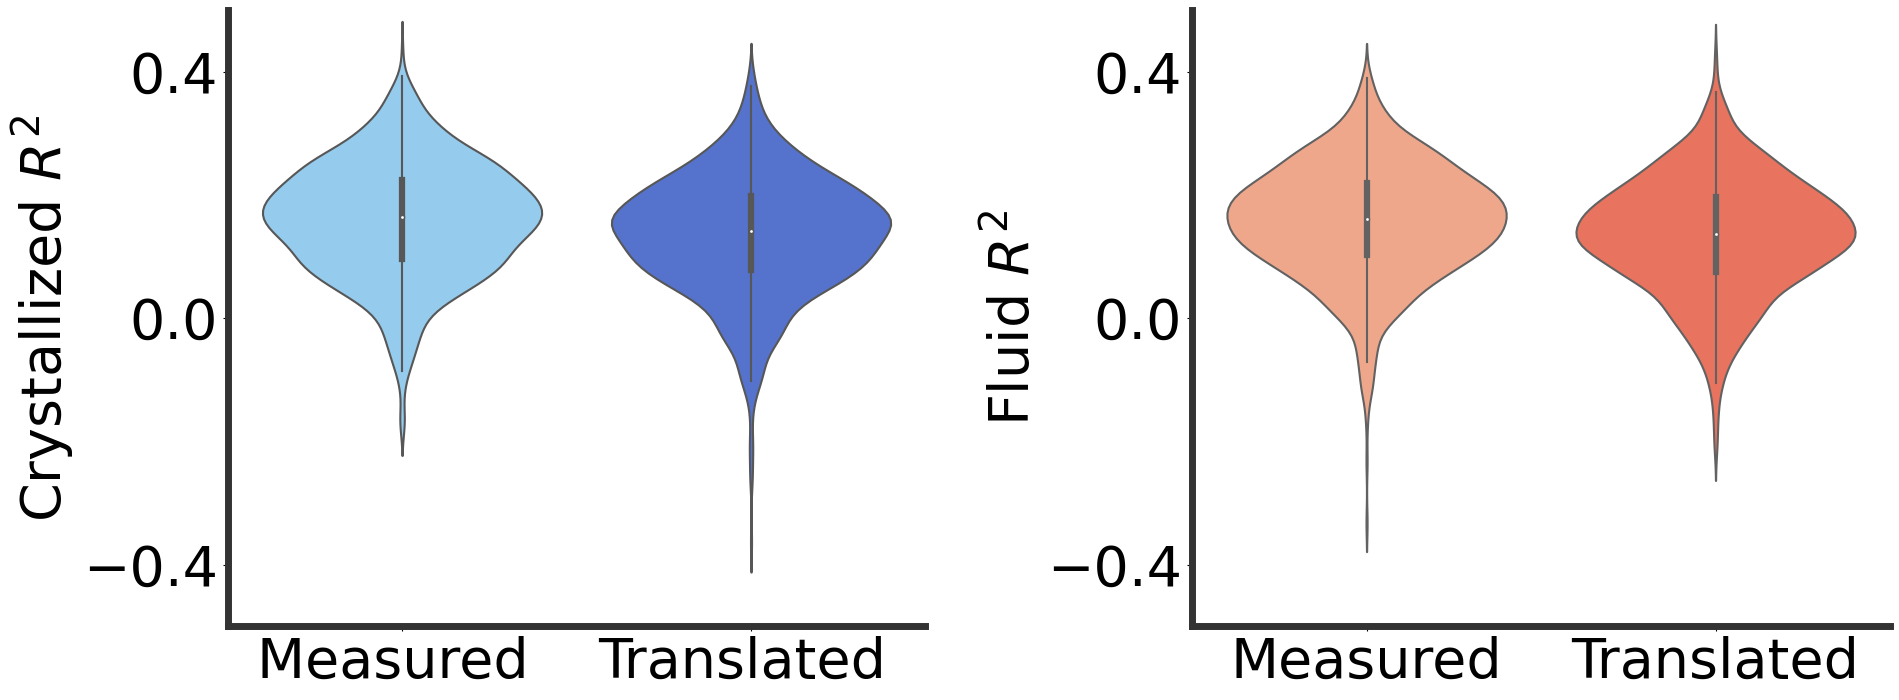

In [43]:
fig,axes = plt.subplots(1,2,figsize=(20, 8))
axes=axes.flatten()
df_all_behv = pd.DataFrame({
    "Values": np.concatenate([get_r2_measured_crystal.squeeze(), get_r2_translated_crystal.squeeze()]),
    "Groups": ["Measured "] * (len(get_r2_measured_crystal)) + ["Translated "] * len(get_r2_translated_crystal)
})
# axxx=sns.swarmplot(df_all_behv, x="Groups", y="Values", hue="Groups", legend=False, palette=['lightskyblue','royalblue'],ax=axes[0])
axxx=sns.violinplot(df_all_behv, x="Groups", y="Values", hue="Groups", legend=False,  dodge=False, palette=['lightskyblue','royalblue'],ax=axes[0])

# axxx=sns.barplot(df_all_behv, x="Groups", y="Values", hue="Groups", orient="v", estimator='mean', errorbar="sd",
#                  edgecolor='0.2',lw=2.5,errwidth=2.5, dodge=False, palette=['brown','lightsalmon'])
# axxx=sns.histplot(df_all_behv, x="Values", hue="Groups", stat='density', legend=True, palette=['lightskyblue','royalblue'], bins=30, ax=axes[0])
# sns.move_legend(axxx, "lower center", ncol=2, title=None, frameon=False, bbox_to_anchor=(0.5,1))
axxx.get_legend().remove()
for ax in ['bottom','left']:
    axxx.spines[ax].set_linewidth(5)
    axxx.spines[ax].set_color('0.2')
axxx.spines['top'].set_visible(False)
axxx.spines['right'].set_visible(False)
axes[0].set_ylim((-0.5, 0.5))
axes[0].set_yticks([-0.4, 0, 0.4])
axxx.set_ylabel("Crystallized $R^2$")
axxx.set_xlabel("")
# axxx.set_ylabel("")
# axxx.set_xlabel("Crystal $R^2$")

df_all_behv = pd.DataFrame({
    "Values": np.concatenate([get_r2_measured_fluid, get_r2_translated_fluid]),
    "Groups": ["Measured"] * (len(get_r2_measured_fluid)) + ["Translated"] * len(get_r2_translated_fluid)
})
# axxx=sns.swarmplot(df_all_behv, x="Groups", y="Values", hue="Groups", legend=False, palette=['lightsalmon', 'tomato'],ax=axes[1])
axxx=sns.violinplot(df_all_behv, x="Groups", y="Values", hue="Groups", legend=False, dodge=False, palette=['lightsalmon', 'tomato'],ax=axes[1])

# axxx=sns.barplot(df_all_behv, x="Groups", y="Values", hue="Groups", orient="v", estimator='mean', errorbar="sd",
#                  edgecolor='0.2',lw=2.5,errwidth=2.5, dodge=False, palette=['brown','lightsalmon'])
# axxx=sns.histplot(df_all_behv, x="Values", hue="Groups", stat='density', legend=True, palette=['lightsalmon', 'tomato'], bins=30, ax=axes[1])
# sns.move_legend(axxx, "lower center", ncol=2, title=None, frameon=False, bbox_to_anchor=(0.5,1))
for ax in ['bottom','left']:
    axxx.spines[ax].set_linewidth(5)
    axxx.spines[ax].set_color('0.2')
axxx.spines['top'].set_visible(False)
axxx.spines['right'].set_visible(False)
axes[1].set_ylim((-0.5, 0.5))# axxx.spines['left'].set_visible(False)
axes[1].set_yticks([-0.4, 0, 0.4])
# axxx.set(ylabel='')
# plt.yticks([])
axxx.set_ylabel("Fluid $R^2$")
axxx.set_xlabel("")
# axxx.set_xlabel("Fluid $R^2$")

axxx.get_legend().remove()
# axxx.set_xticklabels(axxx.get_xticklabels(), rotation=45, ha='right')
# axxx.set_title("R^2 Across bootstraps")
# plt.suptitle("Schaeffer 100")
filename = f"/plot_bootstrap_{from_parcellation_list[iidx_model]}_{behv_type}.{img_extension}"
print(f"Saving to path:{directory}")

plt.tight_layout()
plt.show()
# Save the figure
if not local_flag:
    plt.savefig(directory + filename, format=img_extension)


# #significant?
# crystal_sig = across_behv_r2diff[0][0]
# fluid_sig = across_behv_r2diff[1][0]
# # plt.hist(r2_difference_list)

# diff_c=np.asarray(crystal_sig)
# t_statistic, p_value = stats.ttest_1samp(a=diff_c, popmean=0) #diff from 0?
# print(f"crystal\n tstat:{t_statistic} pval:{p_value}")

# diff_f=np.asarray(fluid_sig)
# t_statistic, p_value = stats.ttest_1samp(a=diff_f, popmean=0) #diff from 0?
# print(f"fluid\n tstat:{t_statistic} pval:{p_value}")

# df_multivariate_significance = pd.DataFrame({
#     "Values": np.concatenate([diff_c, diff_f]),
#     "Groups": ["crystal"] * (len(diff_c)) + ["fluid"] * len(diff_f)
# })
# # print(df_multivariate_significance.head())
# df_multivariate_significance.to_csv(directory+f"/multivariate_sig_{from_parcellation_list[iidx_model]}.csv")

4950 4950
4950 4950
r=0.44
Saving to path:/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/scienceadv_image


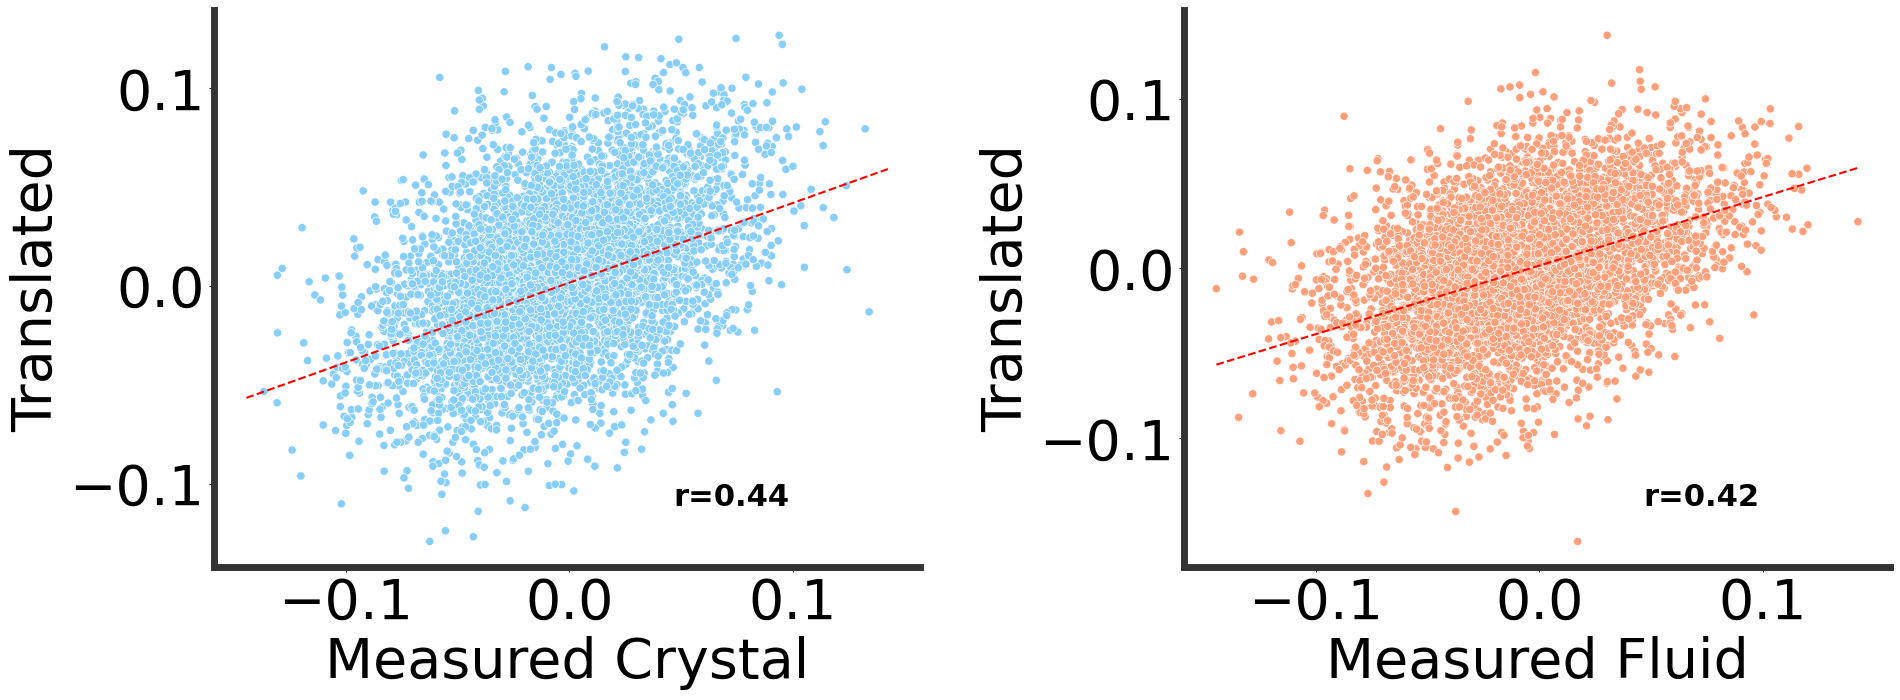

In [44]:
truebb_cryst=np.asarray(behv_list_final[0][3]).squeeze()
predbb_cryst=np.asarray(behv_list_final[0][4]).squeeze()
print(len(truebb_cryst), len(predbb_cryst))
truebb_fluid=np.asarray(behv_list_final[1][3]).squeeze()
predbb_fluid=np.asarray(behv_list_final[1][4]).squeeze()
print(len(truebb_fluid), len(predbb_fluid))
true_translated_corr_crystal = behv_true_pred_corr[0]
true_translated_corr_fluid=behv_true_pred_corr[1] 

df_scatter_crystal = pd.DataFrame({
    "Measured Crystal": truebb_cryst,
    "Translated Crystal": predbb_cryst,
    "Measured Fluid": truebb_fluid,
    "Translated Fluid": predbb_fluid,
    "Groups": ["Connectomes"] * (len(truebb_cryst))
})
df_scatter_crystal.to_csv(directory+f"/univariate_results_{from_parcellation_list[iidx_model]}.csv")

fig,axes = plt.subplots(1,2,figsize=(20, 8))
axes=axes.flatten()
xii=0
# axes[xii].scatter(truebb_cryst, predbb_cryst, c='k', alpha=0.5, vmin=-.2, vmax=.2)
sns.scatterplot(df_scatter_crystal, x="Measured Crystal",y="Translated Crystal", ax=axes[xii], hue="Groups", palette=['lightskyblue'],legend=False)

for ax in ['bottom', 'left']:
    axes[xii].spines[ax].set_linewidth(5)
    axes[xii].spines[ax].set_color('0.2')
axes[xii].spines['top'].set_visible(False)
axes[xii].spines['right'].set_visible(False)
axes[xii].set_xlabel("Measured Crystal")
axes[xii].set_ylabel("Translated")
corr_text=f"r={true_translated_corr_crystal:.2f}"
print(corr_text)
axes[xii].text(0.65, 0.15, corr_text, transform=axes[xii].transAxes, fontsize=22, verticalalignment='top',weight="bold")
axes[xii].plot(np.unique(truebb_fluid), np.poly1d(np.polyfit(truebb_fluid, predbb_fluid, 1))(np.unique(truebb_fluid)), 'r--')

# axes[xii+1].scatter(truebb_fluid, predbb_fluid, c='k', alpha=0.5)
sns.scatterplot(df_scatter_crystal, x="Measured Fluid" ,y="Translated Fluid", ax=axes[xii+1],  hue="Groups", palette=['lightsalmon'],legend=False)
for ax in ['bottom', 'left']:
    axes[xii+1].spines[ax].set_linewidth(5)
    axes[xii+1].spines[ax].set_color('0.2')
axes[xii+1].spines['top'].set_visible(False)
axes[xii+1].spines['right'].set_visible(False)
axes[xii+1].set_xlabel("Measured Fluid")
axes[xii+1].set_ylabel("Translated")
corr_text=f"r={true_translated_corr_fluid:.2f}"
axes[xii+1].text(0.65, 0.15, corr_text, transform=axes[xii+1].transAxes, fontsize=22, verticalalignment='top', weight="bold")
axes[xii+1].plot(np.unique(truebb_fluid), np.poly1d(np.polyfit(truebb_fluid, predbb_fluid, 1))(np.unique(truebb_fluid)), 'r--')

filename = f"/scatter_behavior_corrs_{from_parcellation_list[iidx_model]}.{img_extension}"
print(f"Saving to path:{directory}")
plt.tight_layout()
plt.show()

# Save the figure
if not local_flag:
    plt.savefig(directory + filename, format=img_extension)


624
0.9990354406949047
0.9975726153408198
0.9994298322679913
0.999436131188508
Count perfect schf100: 329


/Users/snaranjo/miniconda3/envs/dahan_optimus/lib/python3.7/site-packages/ipykernel_launcher.py:31: UserWarning: The palette list has more values (4) than needed (1), which may not be intended.


4950 4950
4950 4950


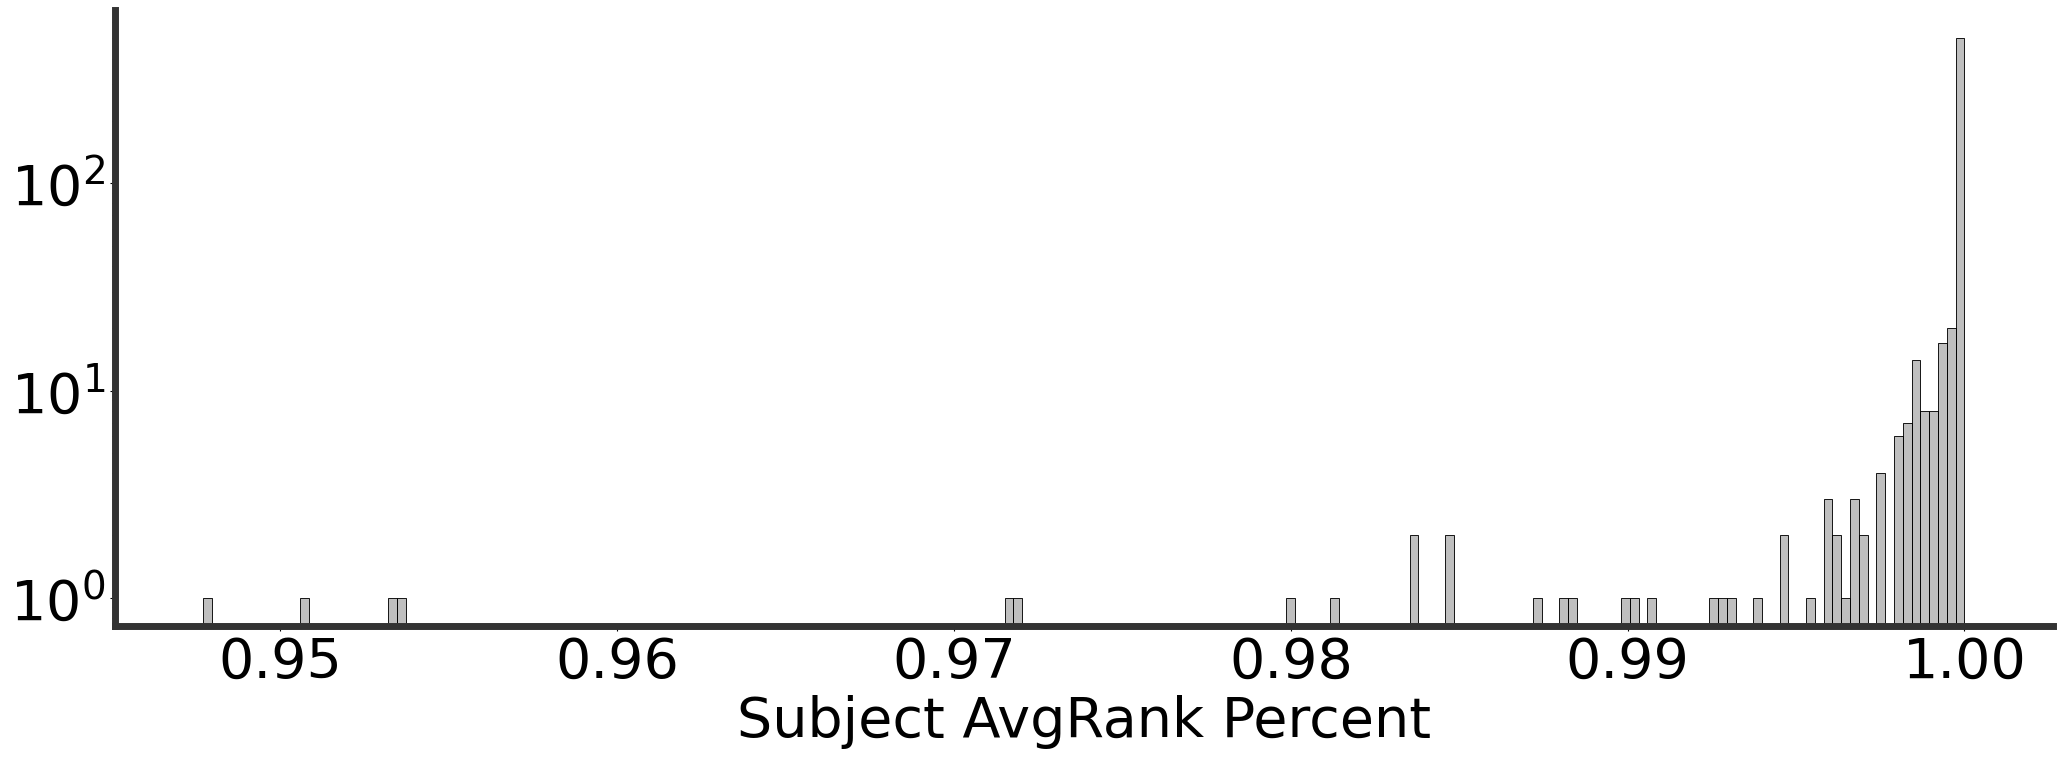

In [ ]:
# Average Rank
test_n = test_true.shape[0]
print(test_n)
train_n = train_true.shape[0]
# 0 because only test is being saved
table_of_test_performance_100 = pd.read_csv(directory100+'/FingerPrintTable_avgrank.csv')["FingerPrintPerformance_avgrank"][:test_n]
table_of_test_performance_100_partial = pd.read_csv(directory100_partial+'/FingerPrintTable_avgrank.csv')["FingerPrintPerformance_avgrank"][:test_n]
table_of_test_performance_300 = pd.read_csv(directory300+'/FingerPrintTable_avgrank.csv')["FingerPrintPerformance_avgrank"][:test_n]
table_of_test_performance_360 = pd.read_csv(directory360+'/FingerPrintTable_avgrank.csv')["FingerPrintPerformance_avgrank"][:test_n]
# print(table_of_test_performance_100.head())
print(np.mean(table_of_test_performance_100))
print(np.mean(table_of_test_performance_100_partial))
print(np.mean(table_of_test_performance_300))
print(np.mean(table_of_test_performance_360))

plt.figure(figsize=(25, 8))
#axes = axes.flatten()
    
# df = pd.DataFrame({
#     "Values": np.concatenate([np.asarray(table_of_test_performance_100), np.asarray(table_of_test_performance_100_partial), np.asarray(table_of_test_performance_300), np.asarray(table_of_test_performance_360)]),
#     "Groups": ["Schaefer 100 AvgRank"] * len(table_of_test_performance_100) + ["Schaefer 100 PC AvgRank"] * len(table_of_test_performance_100) + ["Schaefer 300 AvgRank"] * len(table_of_test_performance_300) + ["Schaefer 360 AvgRank"] * len(table_of_test_performance_360)
# })

df = pd.DataFrame({
    "Values": np.asarray(table_of_test_performance_100),
    "Groups": ["Schaefer 100 AvgRank"] * len(table_of_test_performance_100)
})
axxx=sns.histplot(df,x="Values", hue="Groups", bins=200, log_scale=[False, True], palette=['gray', 'lightsalmon', 'red','darkcyan'])
# sns.move_legend(axxx, "lower center", ncol=2, title=None, frameon=False, bbox_to_anchor=(0.5,1))
axxx.get_legend().remove() #if using bar plot
for ax in ['bottom', 'left']:
    axxx.spines[ax].set_linewidth(5)
    axxx.spines[ax].set_color('0.2')
axxx.spines['top'].set_visible(False)
axxx.spines['right'].set_visible(False)
# axxx.get_legend().remove()
axxx.set_ylabel("")
axxx.set_xlabel("Subject AvgRank Percent")
filename = f"/histogram_avgrank_finger_allconnectomes.{img_extension}"

truebb_cryst=np.asarray(behv_list_final[0][3]).squeeze()
predbb_cryst=np.asarray(behv_list_final[0][4]).squeeze()
print(len(truebb_cryst), len(predbb_cryst))
truebb_fluid=np.asarray(behv_list_final[1][3]).squeeze()
predbb_fluid=np.asarray(behv_list_final[1][4]).squeeze()
print(len(truebb_fluid), len(predbb_fluid))
true_translated_corr_crystal = behv_true_pred_corr[0]
true_translated_corr_fluid=behv_true_pred_corr[1] 

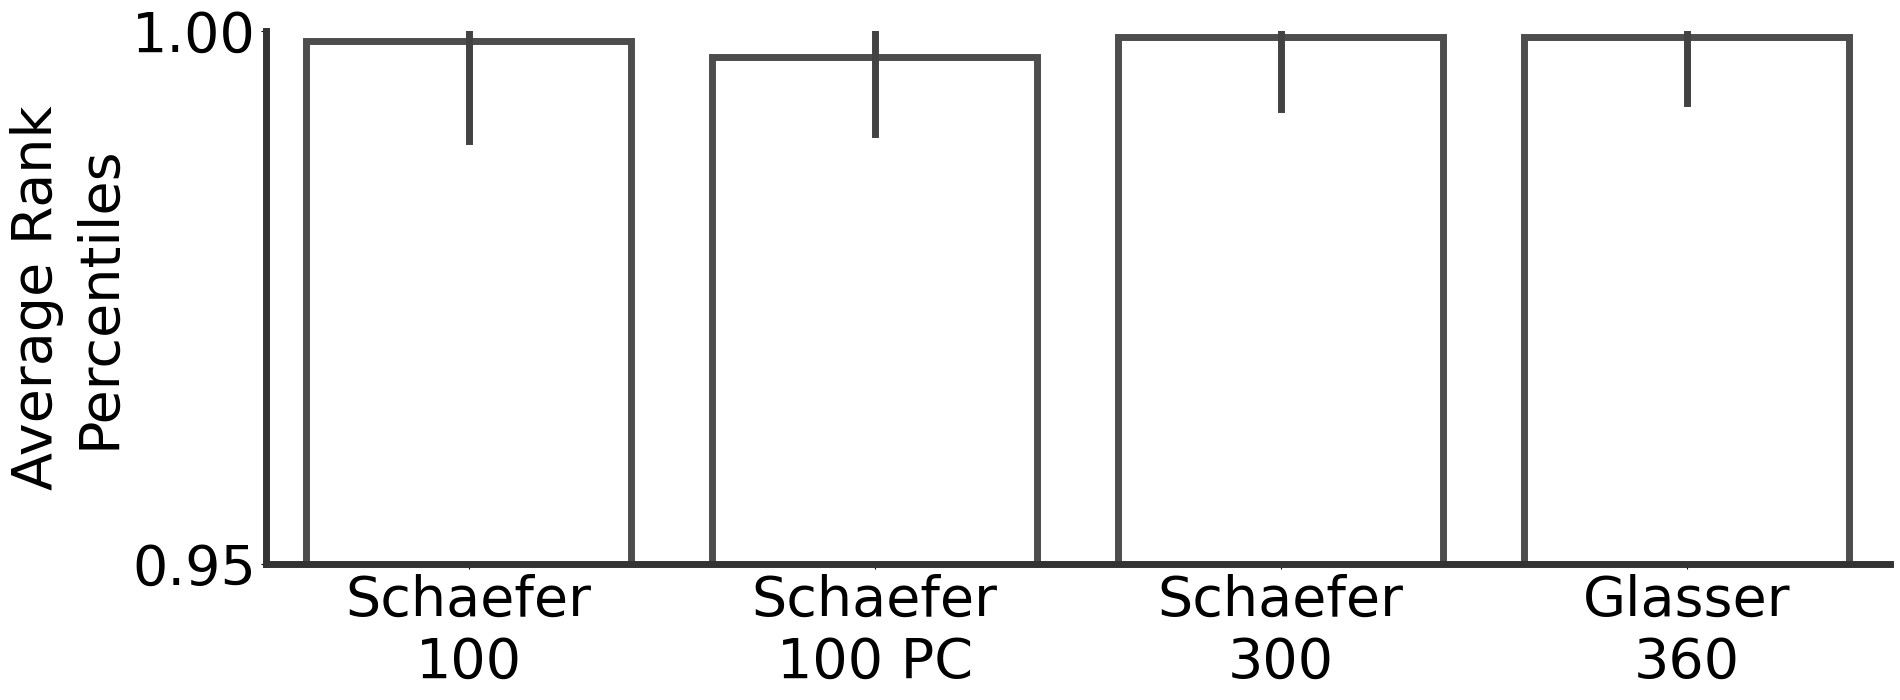

329.0
3.0
72.0
152.0


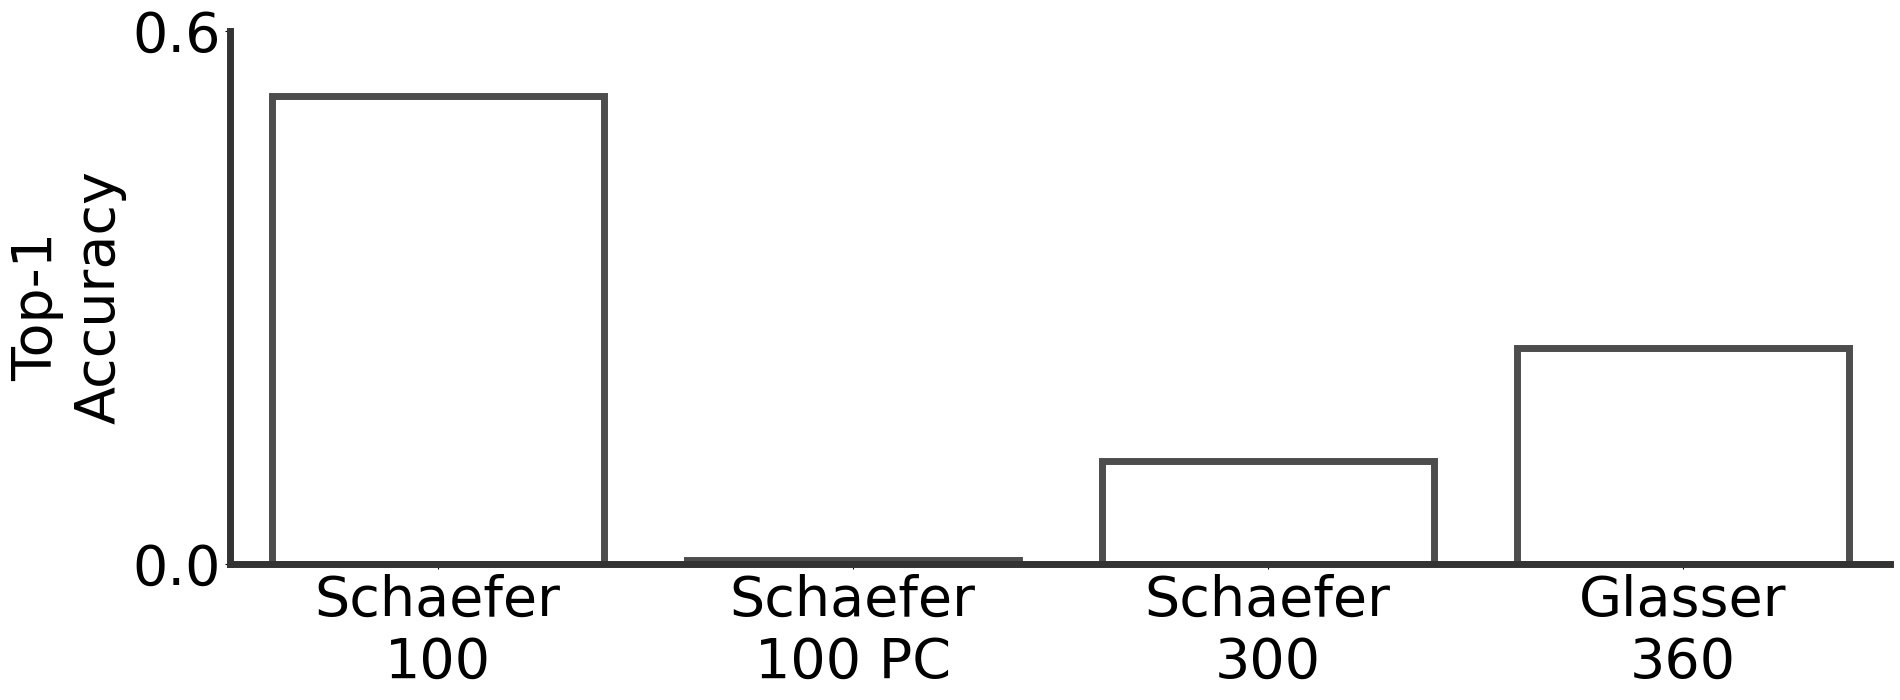

In [60]:

df = pd.DataFrame({
    "Values": np.concatenate([table_of_test_performance_100.to_numpy(), table_of_test_performance_100_partial.to_numpy(), table_of_test_performance_300.to_numpy(), table_of_test_performance_360.to_numpy()]),
    "Groups": ["Schaefer\n100"]*len(table_of_test_performance_100) + ["Schaefer\n100 PC"]*len(table_of_test_performance_100_partial) + ["Schaefer\n300"]*len(table_of_test_performance_300) + ["Glasser\n360"]*len(table_of_test_performance_360)
})

plt.figure(figsize=(20, 8))
# palette=['gray','lightsalmon','red','cyan']
axxx=sns.barplot(df,x="Groups", y="Values", hue="Groups", palette=['gray','lightsalmon','red','cyan'],
                 errorbar=("sd",2), edgecolor='0.3', lw=5, errwidth=5, dodge=False,facecolor=(0, 0, 0, 0))
# for bar, alpha in zip(axxx.collections[::2], [0, 0, 0, 0]):
#     bar.set_facecolor(to_rgba(bar.get_facecolor(), alpha=alpha))
# axxx.bar_label({axxx.containers[0]}, fontsize=10) # to number the top of each barplot with its number
# sns.move_legend(axxx, "lower center", ncol=2, title=None, frameon=False, bbox_to_anchor=(0.5,1))
axxx.get_legend().remove() #if using bar plot
for ax in ['bottom', 'left']:
    axxx.spines[ax].set_linewidth(5)
    axxx.spines[ax].set_color('0.2')
axxx.spines['top'].set_visible(False)
axxx.spines['right'].set_visible(False)
# axxx.set_xticklabels(axxx.get_xticklabels(), rotation=35, ha='right')
axxx.set(ylim=(0.96, 1))
axxx.set_yticks([0.95, 1])
axxx.set_ylabel("Average Rank\nPercentiles", fontsize=40)
axxx.set_xlabel("")
filename = f"/barplot_avgrank_allconnectomes.{img_extension}"

plt.tight_layout()
plt.show()

### REPEAT FOR TOP-1 ACCURACY
table_of_test_performance_top1_100 = pd.read_csv(directory100+'/FingerPrintTable.csv')["Values"][:test_n].sum()
table_of_test_performance_top1_100_partial = pd.read_csv(directory100_partial+'/FingerPrintTable.csv')["Values"][:test_n].sum()
table_of_test_performance_top1_300 = pd.read_csv(directory300+'/FingerPrintTable.csv')["Values"][:test_n].sum()
table_of_test_performance_top1_360 = pd.read_csv(directory360+'/FingerPrintTable.csv')["Values"][:test_n].sum()
print((table_of_test_performance_top1_100))
print((table_of_test_performance_top1_100_partial))
print((table_of_test_performance_top1_300))
print((table_of_test_performance_top1_360))

top1_np = np.zeros((4,))
top1_np[0]=table_of_test_performance_top1_100 / test_n
top1_np[1]=table_of_test_performance_top1_100_partial / test_n
top1_np[2]=table_of_test_performance_top1_300 / test_n
top1_np[3]=table_of_test_performance_top1_360 / test_n

df = pd.DataFrame({
    "Values": top1_np,
    "Groups": ["Schaefer\n100"] + ["Schaefer\n100 PC"]+ ["Schaefer\n300"] + ["Glasser\n360"]
})

plt.figure(figsize=(20, 8))
# palette=['gray','lightsalmon','red','cyan']
axxx=sns.barplot(df,x="Groups", y="Values", hue="Groups",  palette=['gray','lightsalmon','red','cyan'],
                 errorbar=None, edgecolor='0.3', lw=5, dodge=False,facecolor=(0, 0, 0, 0))
axxx.get_legend().remove() #if using bar plot
for ax in ['bottom', 'left']:
    axxx.spines[ax].set_linewidth(5)
    axxx.spines[ax].set_color('0.2')
axxx.spines['top'].set_visible(False)
axxx.spines['right'].set_visible(False)
# axxx.set_xticklabels(axxx.get_xticklabels(), rotation=35, ha='right')
# axxx.set(ylim=(0.96, 1))
axxx.set_yticks([0, 0.6])
axxx.set_ylabel("Top-1 \nAccuracy", fontsize=40)
axxx.set_xlabel("")
filename = f"/barplot_top1acc_allconnectomes.{img_extension}"

plt.tight_layout()
plt.show()

8
0.4386077892970702 0.42336901089821183 0.09829091405965301
(8,)


Text(0.5, 0, '')

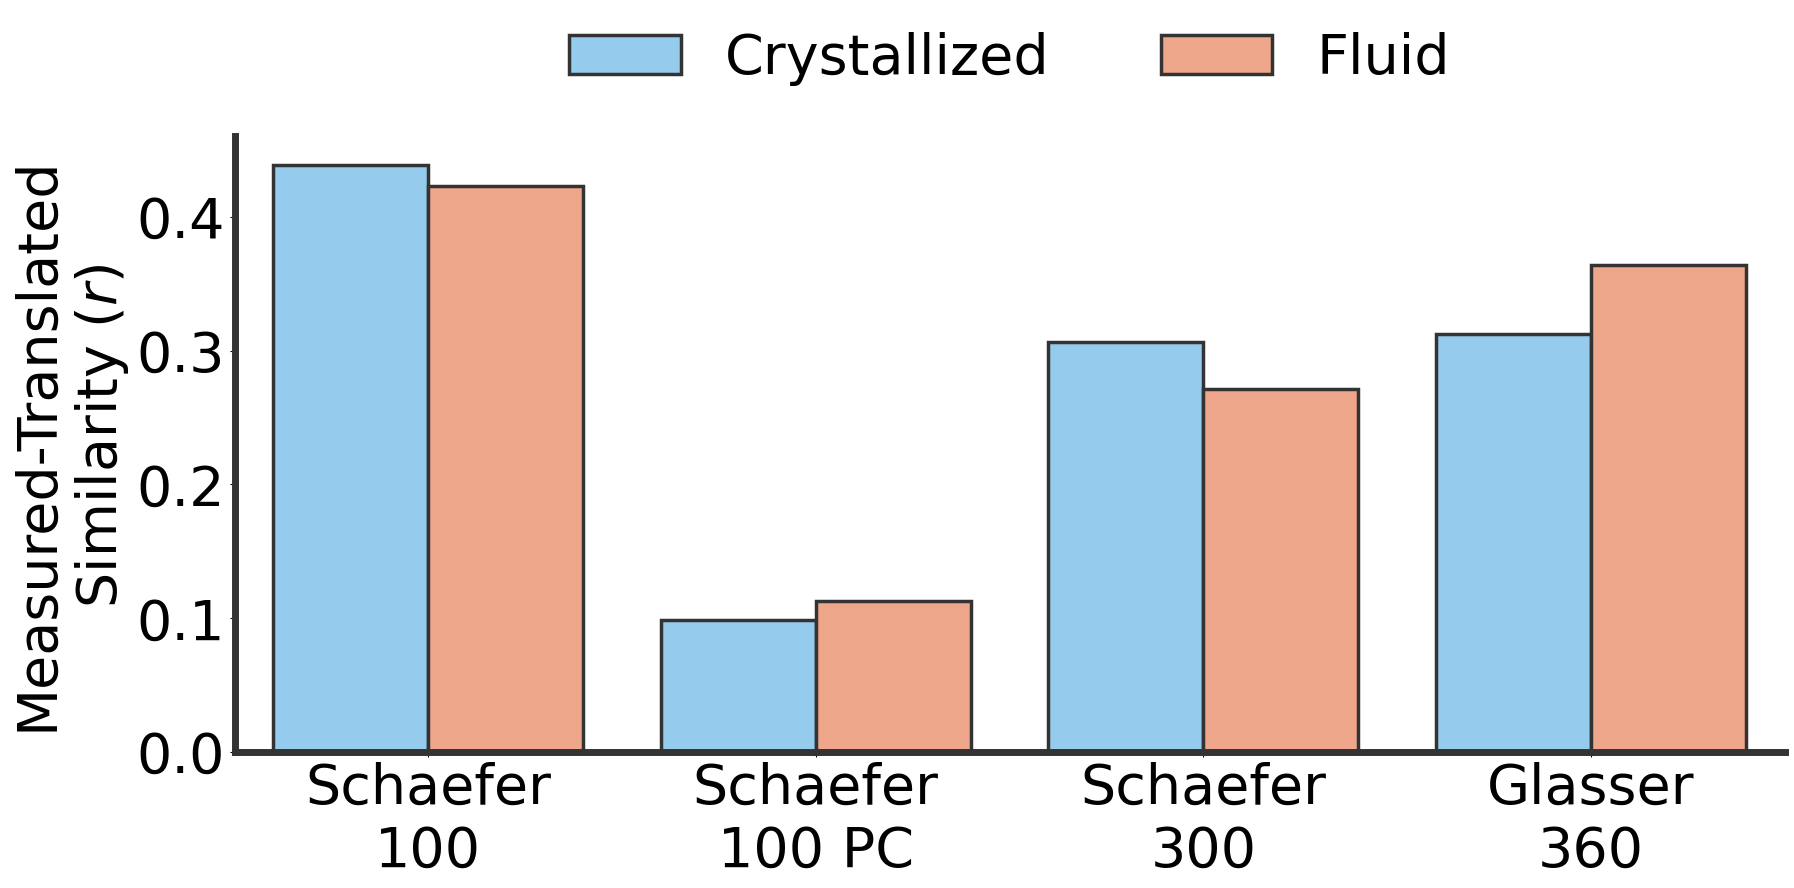

In [22]:
# univariate results

all_connectomes_list = [100, 0, 300, 360]
univariate_results_list=[]
for iidx in range(0, len(all_connectomes_list)):
    curr_parcellation_iteration=all_connectomes_list[iidx]

    if curr_parcellation_iteration == 0:
        directory_r2 = directory+'/partial_100'
        curr_parcellation_iteration=100
        partial_part = "_partial"
    else:
        directory_r2 = directory
        partial_part = ""
   
    # upper_tri_ele = ((curr_parcellation_iteration*(curr_parcellation_iteration-1))//2)
     
    # CRYSTAL
    get_r2_measured_crystal = pd.read_csv(directory_r2+f'/univariate_results_{curr_parcellation_iteration}{partial_part}.csv')
    organize_r2_measured_crystal = get_r2_measured_crystal["Measured Crystal"] #Translated Crystal
    r2_measured_crystal = np.asarray(organize_r2_measured_crystal)

    get_r2_translated_crystal = pd.read_csv(directory_r2+f'/univariate_results_{curr_parcellation_iteration}{partial_part}.csv')
    organize_r2_translated_crystal = get_r2_translated_crystal["Translated Crystal"]
    r2_translated_crystal = np.asarray(organize_r2_translated_crystal)

    # correlation between measured and transalted crystal
    crystal_measured_translated_corr = np.corrcoef(r2_measured_crystal,r2_translated_crystal)[0,1]
    univariate_results_list.append(crystal_measured_translated_corr)

    # # FLUID
    get_r2_measured_fluid = pd.read_csv(directory_r2+f'/univariate_results_{curr_parcellation_iteration}{partial_part}.csv')
    organize_r2_measured_fluid = get_r2_measured_fluid["Measured Fluid"]
    r2_measured_fluid = np.asarray(organize_r2_measured_fluid)

    get_r2_translated_fluid = pd.read_csv(directory_r2+f'/univariate_results_{curr_parcellation_iteration}{partial_part}.csv')
    organize_r2_translated_fluid = get_r2_translated_fluid["Translated Fluid"]
    r2_translated_fluid = np.asarray(organize_r2_translated_fluid)

    #corr between measured and translated fluid
    fluid_measured_translated_corr = np.corrcoef(r2_measured_fluid,r2_translated_fluid)[0,1]
    univariate_results_list.append(fluid_measured_translated_corr)

    #univariate_results_list is list of [corr(true,translated) for crystal, & fluid]100, [-]100PC, [-]300, [-]360
    
print(len(univariate_results_list))
print(univariate_results_list[0], univariate_results_list[1], univariate_results_list[2])
print(np.asarray(univariate_results_list).shape) #should be size (8,) and eith above order [-]100,[-]100pc...


df_univariate_allconnectomes = pd.DataFrame({
    "Values": np.asarray(univariate_results_list),
    "Groups": ["Crystallized"] + ["Fluid"]
    + ["Crystallized"] + ["Fluid"]
    + ["Crystallized"] + ["Fluid"]
    +["Crystallized"] + ["Fluid"],
    "Connectomes": ["Schaefer\n100"]*2 + ["Schaefer\n100 PC"]*2+ ["Schaefer\n300"]*2 + ["Glasser\n360"]*2
})
# print(df_univariate_allconnectomes)

# df_list_palette.append(['gray','lightsalmon','red','cyan'])
fig = plt.figure(figsize=(20, 8))
axxx=sns.barplot(df_univariate_allconnectomes, x="Connectomes", y="Values", hue="Groups",
    errorbar=None, lw=2.5, edgecolor="0.2", palette=['lightskyblue','lightsalmon'])
# sns.move_legend(axxx, "lower center", ncol=1, title=None, frameon=False, bbox_to_anchor=(1.15,0.5))
sns.move_legend(axxx, "lower center", ncol=2, title=None, frameon=False, bbox_to_anchor=(0.5,1))
# axxx.get_legend().remove()
for ax in ['bottom','left']:
    axxx.spines[ax].set_linewidth(5)
    axxx.spines[ax].set_color('0.2')
axxx.spines['top'].set_visible(False)
axxx.spines['right'].set_visible(False)
axxx.set_ylabel("Measured-Translated\n Similarity ($r$)")
axxx.set_xlabel("")



(2000,)
(2000,)
(2000,)
(2000,)
(2000, 4)


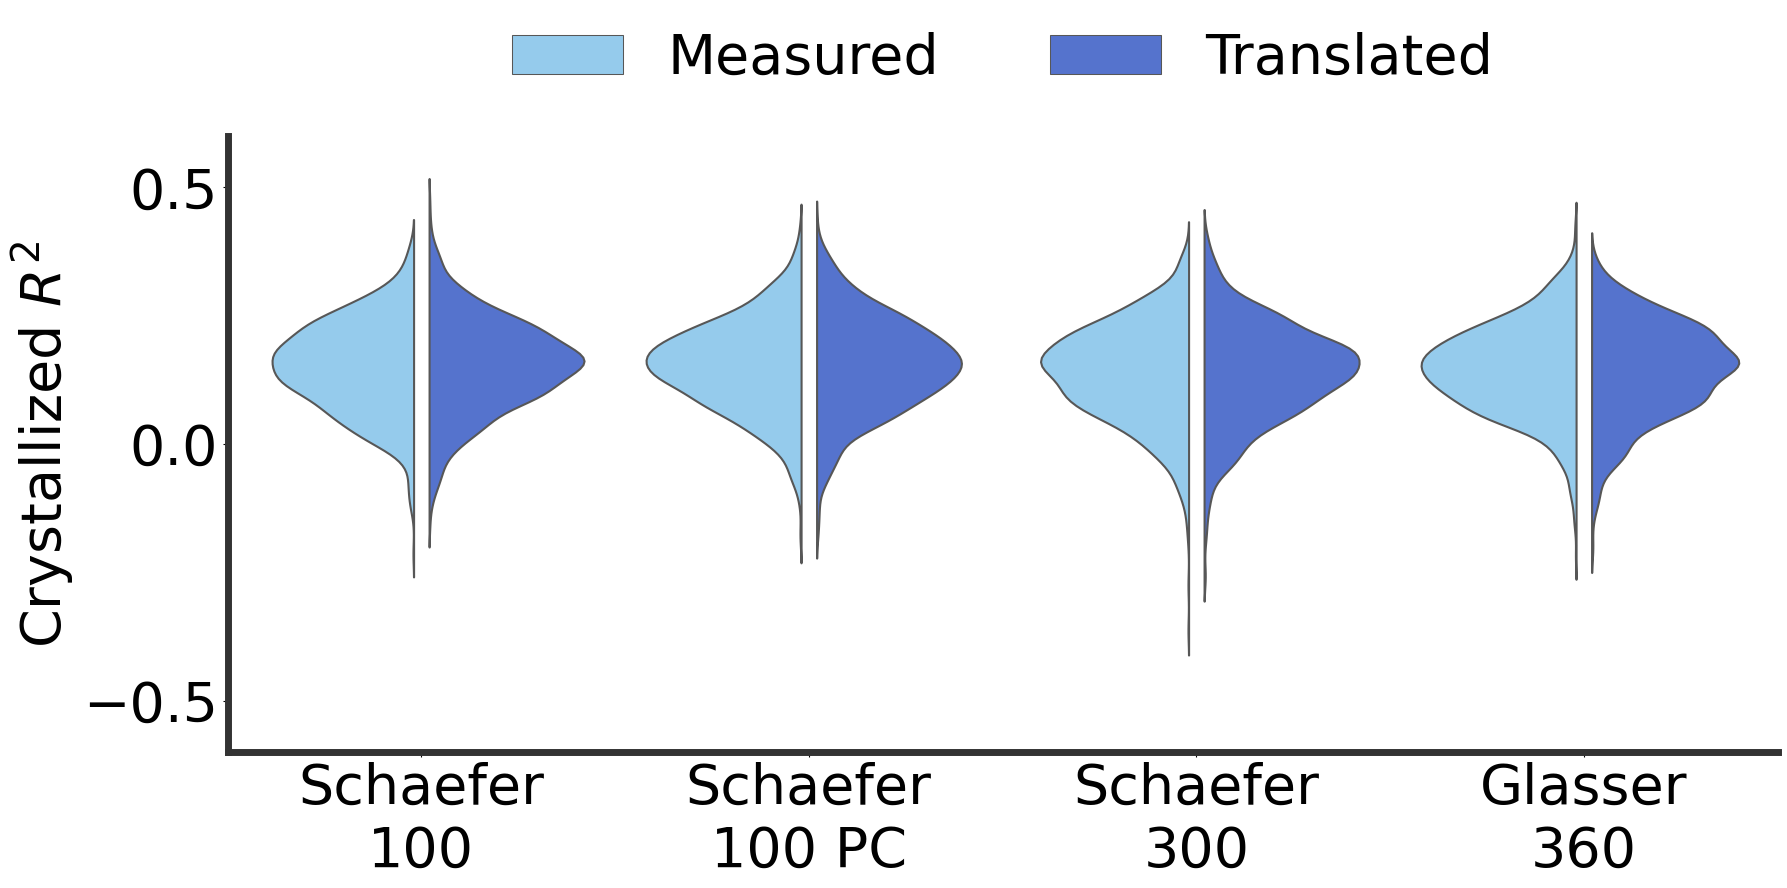

In [23]:
# multivariate results
last_combination = np.zeros((2000,4))
all_connectomes_list = [100, 0, 300, 360]
for iidx in range(0,len(all_connectomes_list)):
    curr_parcellation_iteration=all_connectomes_list[iidx]

    if curr_parcellation_iteration == 0:
        directory_r2 = directory+'/partial_100'
        curr_parcellation_iteration=100
        partial_part = "_partial"
    else:
        directory_r2 = directory
        partial_part = ""
    
    
    # CRYSTAL
    get_r2_measured_crystal = pd.read_csv(directory_r2+f'/r2_calcualtions_{curr_parcellation_iteration}{partial_part}.csv')
    organize_r2_measured_crystal = get_r2_measured_crystal[get_r2_measured_crystal['Groups'] == "measured_crystal"]
    r2_measured_crystal = np.asarray(organize_r2_measured_crystal["Values"])

    get_r2_translated_crystal = pd.read_csv(directory_r2+f'/r2_calcualtions_{curr_parcellation_iteration}{partial_part}.csv')
    organize_r2_translated_crystal = get_r2_translated_crystal[get_r2_translated_crystal['Groups'] == "translated_crystal"]
    r2_translated_crystal = np.asarray(organize_r2_translated_crystal["Values"])

    # # FLUID
    # get_r2_measured_fluid = pd.read_csv(directory_r2+f'/r2_calcualtions_{curr_parcellation_iteration}{partial_part}.csv')
    # organize_r2_measured_fluid = get_r2_measured_fluid[get_r2_measured_fluid['Groups'] == "measured_fluid"]
    # r2_measured_fluid = np.asarray(organize_r2_measured_fluid["Values"])

    # get_r2_translated_fluid = pd.read_csv(directory_r2+f'/r2_calcualtions_{curr_parcellation_iteration}{partial_part}.csv')
    # organize_r2_translated_fluid = get_r2_translated_fluid[get_r2_translated_fluid['Groups'] == "translated_fluid"]
    # r2_translated_fluid = np.asarray(organize_r2_translated_fluid["Values"])
    
    # concat_above=np.concatenate((r2_measured_crystal, r2_translated_crystal, r2_measured_fluid, r2_translated_fluid))
    concat_above=np.concatenate((r2_measured_crystal, r2_translated_crystal))
    print(concat_above.shape)
    last_combination[:,iidx] = concat_above
print(last_combination.shape)

df_r2_allconnectomes = pd.DataFrame({
    "Values": last_combination.flatten(),
    "Groups": ["Measured"]*1000 + ["Translated"]*1000
    + ["Measured"]*1000 + ["Translated"]*1000
    +["Measured"]*1000 + ["Translated"]*1000
    + ["Measured"]*1000 + ["Translated"]*1000,
    "Connectomes": ["Schaefer\n100"]*len(concat_above) + ["Schaefer\n100 PC"]*len(concat_above)+ ["Schaefer\n300"]*len(concat_above) + ["Glasser\n360"]*len(concat_above)
})

fig = plt.figure(figsize=(20, 8))
axxx=sns.violinplot(df_r2_allconnectomes, x="Connectomes", y="Values", hue="Groups", legend=False,  split=True, palette=['lightskyblue','royalblue'], inner=None)
sns.move_legend(axxx, "lower center", ncol=2, title=None, frameon=False, bbox_to_anchor=(0.5,1))
# axxx.get_legend().remove()
for ax in ['bottom','left']:
    axxx.spines[ax].set_linewidth(5)
    axxx.spines[ax].set_color('0.2')
axxx.spines['top'].set_visible(False)
axxx.spines['right'].set_visible(False)
axxx.set_ylim((-0.6, 0.6))
axxx.set_yticks([-0.5, 0, 0.5])
axxx.set_ylabel("Crystallized $R^2$")
axxx.set_xlabel("")

# offset stuff
delta = 0.02
inner=None
import matplotlib.collections
for ii, item in enumerate(axxx.collections):
    # axis contains PolyCollections and PathCollections
    if isinstance(item, matplotlib.collections.PolyCollection):
        # get path
        path, = item.get_paths()
        vertices = path.vertices

        # shift x-coordinates of path
        if not inner:
            if ii % 2: # -> to right
                vertices[:,0] += delta
            else: # -> to left
                vertices[:,0] -= delta
        else: # inner='box' adds another type of PollyCollection
            if ii % 3 == 0:
                vertices[:,0] -= delta
            elif ii % 3 == 1:
                vertices[:,0] += delta
            else: # ii % 3 = 2
                pass

plt.show()

(2000,)
(2000,)
(2000,)
(2000,)
(2000, 4)


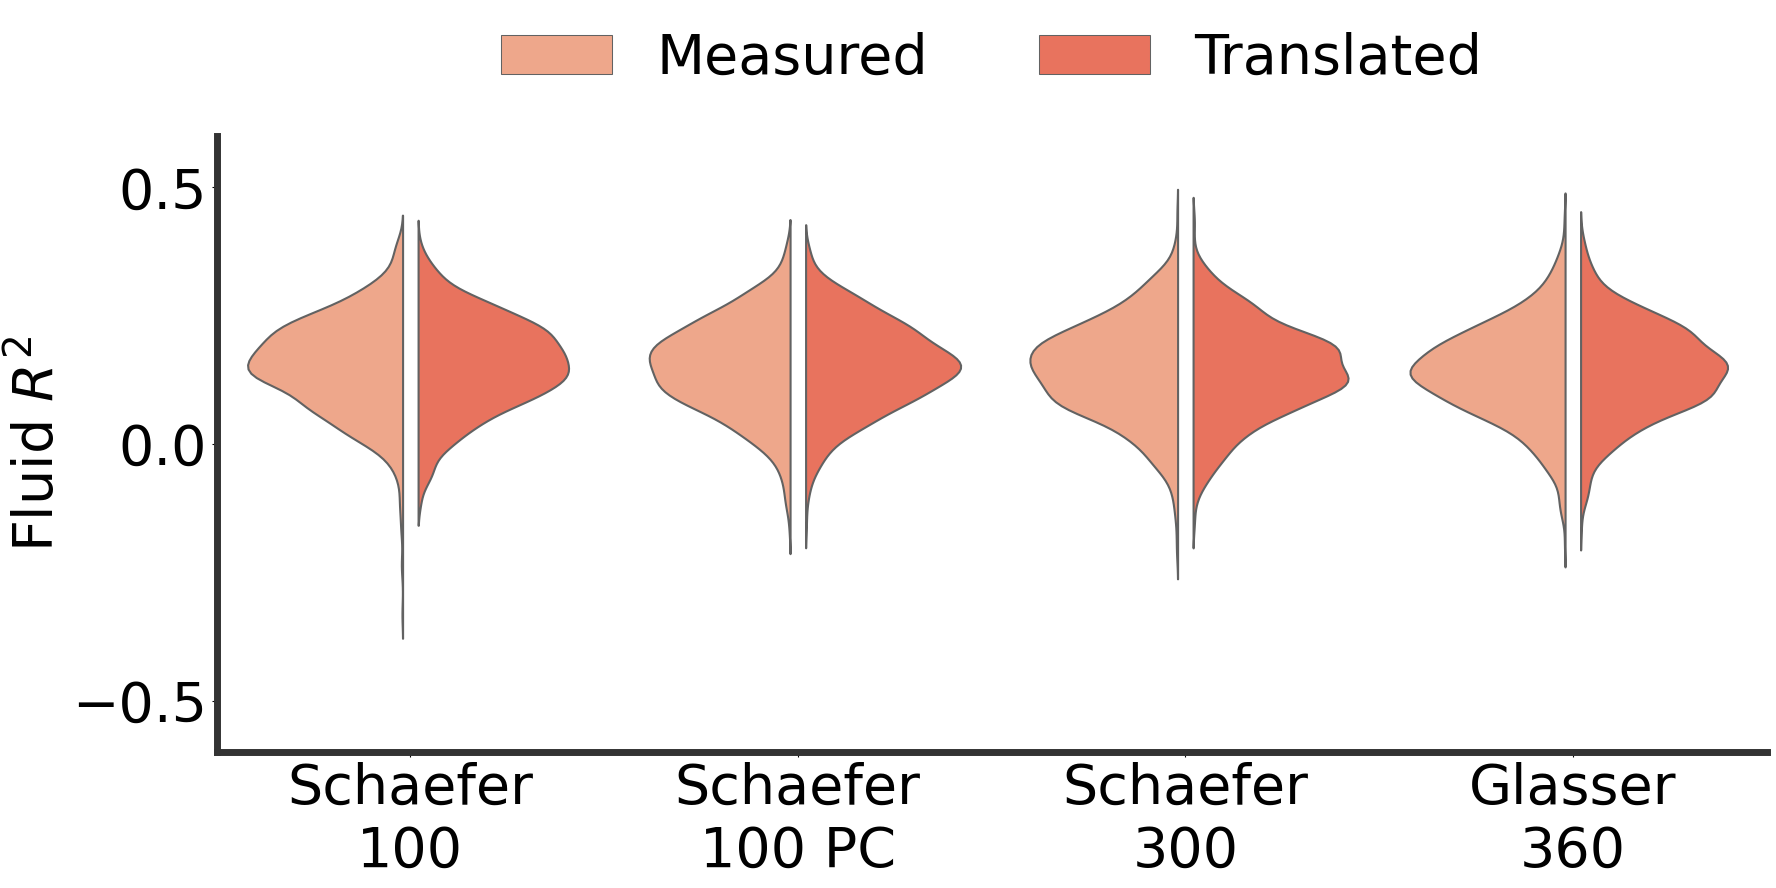

In [24]:
# multivariate results
last_combination = np.zeros((2000,4))
all_connectomes_list = [100, 0, 300, 360]
for iidx in range(0,len(all_connectomes_list)):
    curr_parcellation_iteration=all_connectomes_list[iidx]

    if curr_parcellation_iteration == 0:
        directory_r2 = directory+'/partial_100'
        curr_parcellation_iteration=100
        partial_part = "_partial"
    else:
        directory_r2 = directory
        partial_part = ""

    # FLUID
    get_r2_measured_fluid = pd.read_csv(directory_r2+f'/r2_calcualtions_{curr_parcellation_iteration}{partial_part}.csv')
    organize_r2_measured_fluid = get_r2_measured_fluid[get_r2_measured_fluid['Groups'] == "measured_fluid"]
    r2_measured_fluid = np.asarray(organize_r2_measured_fluid["Values"])

    get_r2_translated_fluid = pd.read_csv(directory_r2+f'/r2_calcualtions_{curr_parcellation_iteration}{partial_part}.csv')
    organize_r2_translated_fluid = get_r2_translated_fluid[get_r2_translated_fluid['Groups'] == "translated_fluid"]
    r2_translated_fluid = np.asarray(organize_r2_translated_fluid["Values"])
    
    concat_above=np.concatenate((r2_measured_fluid, r2_translated_fluid))
    print(concat_above.shape)
    last_combination[:,iidx] = concat_above
print(last_combination.shape)

df_r2_allconnectomes = pd.DataFrame({
    "Values": last_combination.flatten(),
    "Groups": ["Measured"]*1000 + ["Translated"]*1000
    + ["Measured"]*1000 + ["Translated"]*1000
    + ["Measured"]*1000 + ["Translated"]*1000
    + ["Measured"]*1000 + ["Translated"]*1000,
    "Connectomes": ["Schaefer\n100"]*len(concat_above) + ["Schaefer\n100 PC"]*len(concat_above)+ ["Schaefer\n300"]*len(concat_above) + ["Glasser\n360"]*len(concat_above)
})

fig = plt.figure(figsize=(20, 8))

axxx=sns.violinplot(df_r2_allconnectomes, x="Connectomes", y="Values", hue="Groups", legend=False,  split=True, palette=['lightsalmon','tomato'], inner=None)
sns.move_legend(axxx, "lower center", ncol=2, title=None, frameon=False, bbox_to_anchor=(0.5,1))
# axxx.get_legend().remove()
for ax in ['bottom','left']:
    axxx.spines[ax].set_linewidth(5)
    axxx.spines[ax].set_color('0.2')
axxx.spines['top'].set_visible(False)
axxx.spines['right'].set_visible(False)
axxx.set_ylim((-0.6, 0.6))
axxx.set_yticks([-0.5, 0, 0.5])
axxx.set_ylabel("Fluid $R^2$")
axxx.set_xlabel("")

# offset stuff
delta = 0.02
inner=None
import matplotlib.collections
for ii, item in enumerate(axxx.collections):
    # axis contains PolyCollections and PathCollections
    if isinstance(item, matplotlib.collections.PolyCollection):
        # get path
        path, = item.get_paths()
        vertices = path.vertices

        # shift x-coordinates of path
        if not inner:
            if ii % 2: # -> to right
                vertices[:,0] += delta
            else: # -> to left
                vertices[:,0] -= delta
        else: # inner='box' adds another type of PollyCollection
            if ii % 3 == 0:
                vertices[:,0] -= delta
            elif ii % 3 == 1:
                vertices[:,0] += delta
            else: # ii % 3 = 2
                pass

plt.show()

schf100 average:0.4070864305352864 SD:0.07956616819715638
Saving to path:/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/scienceadv_image


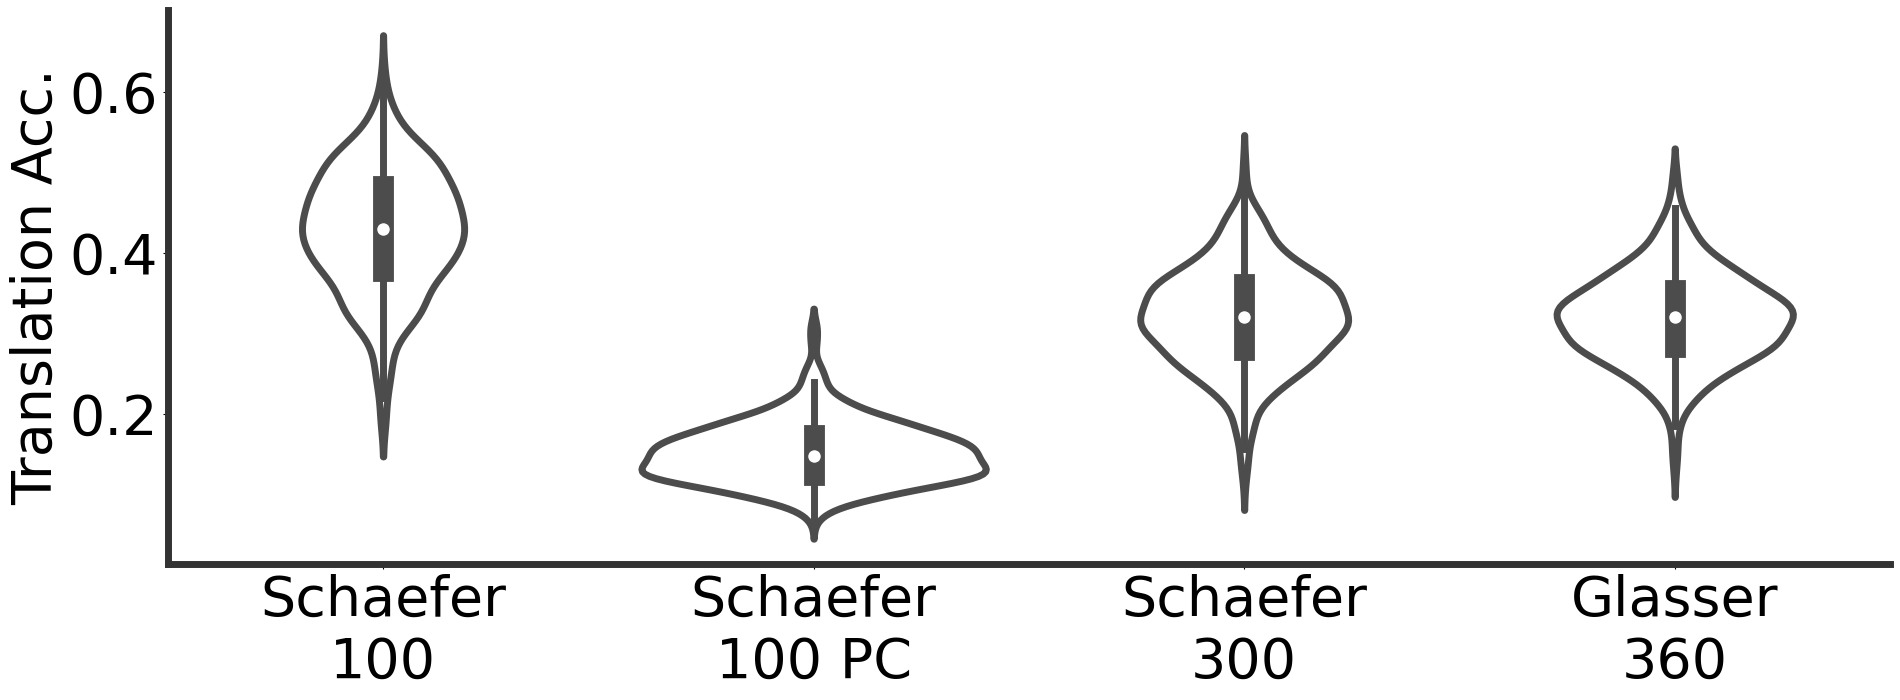

Saving to path:/Users/snaranjo/Desktop/neurotranslate/mount_point/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/images/scienceadv_image


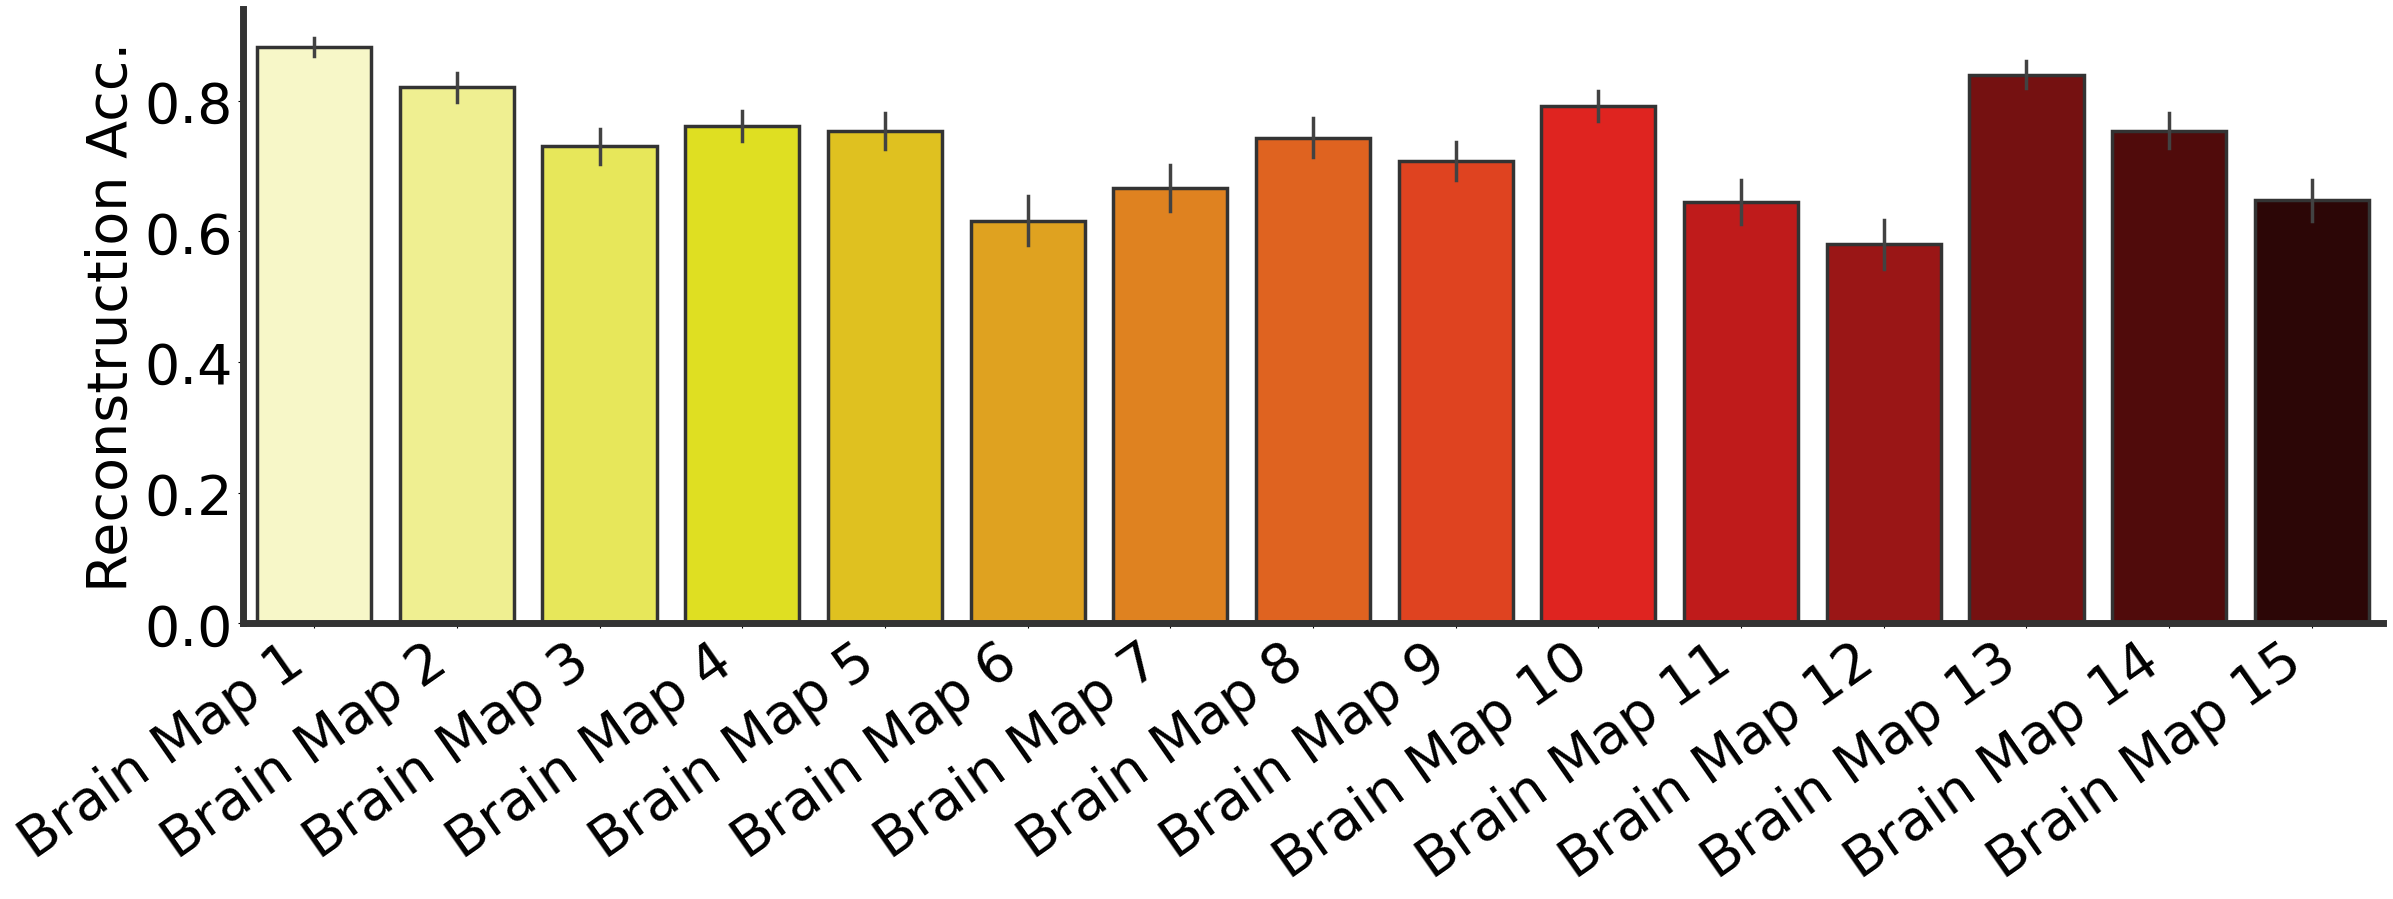

In [25]:
# looking at different ICO
icores=1
store_ico_results = np.zeros((test_n,4))
for ico in range(0,1):
    icores = ico+1
    model_details=f"011426_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp{from_parcellation}_wGelu_ico0{icores}"

    if icores==2:
        model_details="120325_d6h3_tiny_adamW_cosinedecay_recon_MSEtrain_1L_full_demean_exp100_wGelu"
        
    directory100 = root + '/images/ABCD/ICAd15_schfd100/' + model_type +'/' + version + '/' + model_details + '/' + model_test_type 
    translation_ica_schf100 = pd.read_csv(directory100+'/allsubjects_individual_true_pred_testavg.csv')
    translation_ica_schf100 = translation_ica_schf100[translation_ica_schf100['group'] == 'TEST_dmn'] #filter to get test_demean only
    translation_ica_schf100 = np.asarray(translation_ica_schf100["value"])
    print(f"schf100 average:{np.mean(translation_ica_schf100)} SD:{np.std(translation_ica_schf100)}")

    store_ico_results[:,ico] = translation_ica_schf100

# directory100 = root + '/images/ABCD/ICAd15_schfd100/' + model_type +'/' + version + '/' + model_details + '/' +model_test_type 
# translation_ica_schf100 = pd.read_csv(directory100+'/allsubjects_individual_true_pred_testavg.csv')
# translation_ica_schf100 = translation_ica_schf100[translation_ica_schf100['group'] == 'TEST_dmn'] #filter to get test_demean only
# translation_ica_schf100 = translation_ica_schf100['value']
# print(f"schf100 average:{np.mean(translation_ica_schf100)} SD:{np.std(translation_ica_schf100)}")


# from matplotlib.colors import to_rgba
df_list_palette=[]
df_list_palette.append(['gray','lightsalmon','red','cyan'])
if len(df_list)==1:
    fig = plt.figure(figsize=(20, 8))
    for iii in range(len(df_list)):
        # axxx=sns.barplot(df_list[iii], x="Groups", y="Values", hue="Groups", orient="v", estimator='mean', errorbar="sd",
        #     edgecolor='0.2',lw=2.5,errwidth=2.5, dodge=False, palette=df_list_palette[iii],)
        
        # axxx=sns.violinplot(df_list[iii], x="Groups", y="Values", palette=df_list_palette[iii],linewidth=5.0,legend=False)

        axxx=sns.violinplot(df_list[iii], x="Groups", y="Values", palette=df_list_palette[iii], linewidth=5)
        for violin, alpha in zip(axxx.collections[::2], [0, 0, 0, 0]):
            violin.set_facecolor(to_rgba(violin.get_facecolor(), alpha=alpha))

else:
    fig, axes = plt.subplots(1,len(df_list), figsize=(18, 10))
    axes=axes.flatten()
    for iii in range(len(df_list)):
        axxx=sns.barplot(df_list[iii], x="Groups", y="Values", hue="Groups", orient="v", estimator='mean', errorbar="sd",
            edgecolor='0.2',lw=2.5,errwidth=2.5, dodge=False, palette=df_list_palette[iii], ax=axes[iii])
    axxx.get_legend().remove()
for ax in ['bottom','left']:
    axxx.spines[ax].set_linewidth(5)
    axxx.spines[ax].set_color('0.2')
axxx.spines['top'].set_visible(False)
axxx.spines['right'].set_visible(False)
# axxx.set_xticklabels(axxx.get_xticklabels(), rotation=35, ha='right')
axxx.set_ylabel("Translation Acc.")
axxx.set_xlabel("")

filename = f"/violinplot_plot_avgRecon_translations_100_300_360.{img_extension}"
print(f"Saving to path:{directory}")
plt.tight_layout()
# Save the figure
if not local_flag:
    plt.savefig(directory + filename, format=img_extension)
plt.show()


fig = plt.figure(figsize=(25, 10))
# ax=sns.swarmplot(df_ica_individual, x="Groups", y="Values", hue="Groups", legend=False, size=4)
ax=sns.barplot(df_ica_individual, x="Groups", y="Values", orient="v", estimator='mean', errorbar="sd",
                 edgecolor='0.2',lw=2.5,errwidth=2.5, dodge=False, palette="hot_r") #palette=['black','gray'], palette="hot_r", palette=['brown','lightsalmon','mistyrose']
# ax.get_legend().remove() #if using bar plot
for axii in ['bottom','left']:
       ax.spines[axii].set_linewidth(5)
       ax.spines[axii].set_color('0.2')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.set_ylabel("Reconstruction Acc.")
ax.set_xlabel("")
filename = f"/bar_plot_ica_reconstruction.{img_extension}"
print(f"Saving to path:{directory}")
plt.tight_layout()
# Save the figure
if not local_flag:
    plt.savefig(directory + filename, format=img_extension)
plt.show()